# Module 17 BBO Capstone Week 6

## Function 1

For Week 6, you are transitioning from exploration (which you focused on in Weeks 1–5) towards balancing exploration and exploitation. The key shift is that your goal is to begin focusing more on exploiting areas of the domain that are promising based on the data you’ve gathered so far, but still maintaining enough exploration to avoid local optima or missing potential sources.

### Recommendations for Week 6:

#### 1. Reduce Exploration (Lower κ):

In Week 5, you used κ = 6 to prioritize exploration, especially because your data was still sparse, and the output values were very small or close to zero. The model had high uncertainty, so the algorithm focused on sampling regions with large uncertainty.

Now that you have gathered more data and can begin to see trends, reduce κ to 4 for Week 6. This will balance exploration and exploitation. Lowering κ reduces the influence of uncertainty (σ) in the acquisition function, shifting the focus towards exploitation of areas where the model predicts higher values (i.e., where you’ve observed larger outputs).

#### 2. Focus on Exploration + Exploitation:

While κ = 6 was appropriate for ensuring broad coverage of the domain in the early weeks, Week 6 requires a more refined balance.

With κ = 4, your acquisition function will still prioritize regions with high uncertainty but with a stronger focus on regions with higher predicted mean values (μ), where the model predicts good outcomes based on the existing data.

Look for areas in the domain where there may be signals that your model has not fully captured, such as nearby gaps or regions around the few higher-output points you've observed.

#### 3. Query Point Selection (Maximising UCB):

Continue to use the UCB acquisition function for point selection.

You can still use the multi-start optimization method that you implemented for Week 5, which randomly samples potential points (using random starts and restarts) and then maximises the UCB acquisition function to find the next query point.

Focus on refining areas near the middle of the domain (where you had the gap identified by the model in Week 5). You want to gather more information about regions where uncertainty is still high, but there’s a reasonable chance of finding larger outputs.

#### 4. Visualisation and Monitoring:

Keep monitoring your results visually to track how well the GP model is fitting and evolving.

Use the predicted mean and standard deviation (uncertainty) from the GP to identify areas where the model still has high uncertainty, even if those areas aren't at the extreme corners.

#### 5. Strategic Perspective:

Week 6 is about ensuring that you’re starting to zoom in on the regions of the domain that matter most and have the most potential for larger outputs.

By reducing κ, you help the model focus on areas of high reward (i.e., regions near the larger outputs you’ve already seen) while still maintaining some uncertainty in your exploration.

#### Summary for Week 6:

κ = 4: This is a good choice for balancing exploration and exploitation.

Maintain UCB Acquisition: Continue using your existing acquisition function to identify regions of high uncertainty and high predicted values.

Focus on central regions: You’ve seen a gap near the center of the domain, so pay attention to reducing uncertainty around that region. This could lead to finding additional local maxima or sources.

Optimization Strategy: Use multi-start optimization, as before, with 200 random warm-up samples and 40 restarts to ensure thorough exploration while favouring regions that could yield larger outputs.

By doing this, you'll have a better chance of honing in on the areas that maximize the function, leading to a more efficient exploration-exploitation balance.

Week 6 Query Point (UCB, κ=4.0): 0.827328-0.366427


C:\Users\joeat\Documents\Documents\Anaconda3\lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


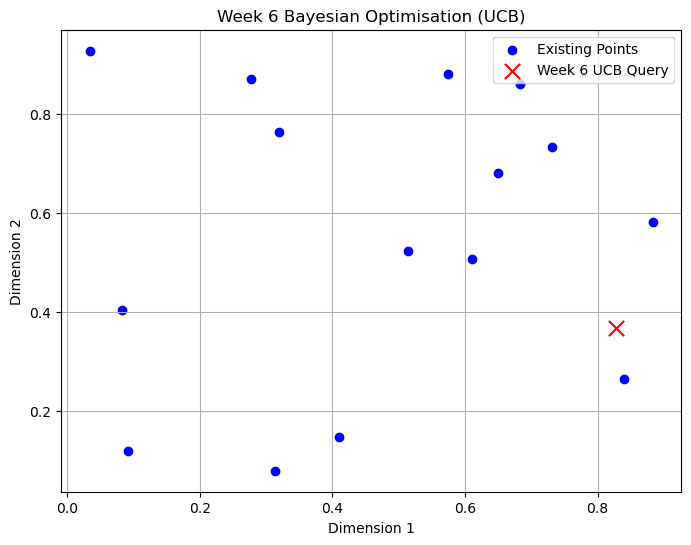

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.optimize import minimize

# ==========================================
# Step 1: Load ALL available data (including Week 5)
# ==========================================

X_train = np.array([
    [0.31940389, 0.76295937],
    [0.57432921, 0.87989810],
    [0.73102363, 0.73299988],
    [0.84035342, 0.26473161],
    [0.65011406, 0.68152635],
    [0.41043714, 0.14755430],
    [0.31269116, 0.07872278],
    [0.68341817, 0.86105746],
    [0.08250725, 0.40348751],
    [0.88388983, 0.58225397],
    [0.60995300, 0.50652000],   
    [0.09106700, 0.11922000],   
    [0.03373400, 0.92780400],
    [0.27783300, 0.86990600],
    [0.51380200, 0.52237900]
])

y_train = np.array([
    1.32267704e-079,
    1.03307824e-046,
    7.71087511e-016,
    3.34177101e-124,
   -3.60606264e-003,
   -2.15924904e-054,
   -2.08909327e-091,
    2.53500115e-040,
    3.60677119e-081,
    6.22985647e-048,
    6.40320490897793e-12,
    3.32695744236522e-140,
   -3.9448560322363033e-284,
   -2.388807237117217e-127,
    5.298471823372752e-14
])

# ==========================================
# Step 2: Fit Gaussian Process
# ==========================================

kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=0.2, length_scale_bounds=(1e-3, 1e3))

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-2,
    normalize_y=True,
    n_restarts_optimizer=15
)

gp.fit(X_train, y_train)

# ==========================================
# Step 3: UCB Acquisition Function (Maximisation) reducing kappa from 6.0 to 4.0
# ==========================================

def ucb(x, model, kappa=4.0):
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    return -(mu + kappa * sigma)  # negative for minimizer

# ==========================================
# Step 4: Multi-start optimisation of UCB
# ==========================================

def optimize_ucb(model, kappa=4.0, n_restarts=40, n_random_starts=200):

    bounds = np.array([[0.0, 1.0], [0.0, 1.0]])

    best_x = None
    best_val = np.inf

    # --- Random warmup sampling (global scan) ---
    random_points = np.random.uniform(0, 1, size=(n_random_starts, 2))
    mu, sigma = model.predict(random_points, return_std=True)
    ucb_values = mu + kappa * sigma

    top_indices = np.argsort(-ucb_values)[:n_restarts]
    start_points = random_points[top_indices]

    # --- Local optimisation from best random starts ---
    for x0 in start_points:
        result = minimize(
            ucb,
            x0,
            args=(model, kappa),
            bounds=bounds,
            method="L-BFGS-B"
        )

        if result.fun < best_val:
            best_val = result.fun
            best_x = result.x

    return best_x

# ==========================================
# Step 5: Get Week 5 Query Point (Exploration)
# ==========================================

next_point = optimize_ucb(gp, kappa=4.0)

next_point_str = f"{next_point[0]:.6f}-{next_point[1]:.6f}"
print(f"Week 6 Query Point (UCB, κ=4.0): {next_point_str}")

# ==========================================
# Step 6: Visualisation
# ==========================================

plt.figure(figsize=(8, 6))

plt.scatter(X_train[:, 0], X_train[:, 1],
            color='blue', label='Existing Points')

plt.scatter(next_point[0], next_point[1],
            color='red', marker='x', s=120,
            label='Week 6 UCB Query')

plt.title("Week 6 Bayesian Optimisation (UCB)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.legend()
plt.grid(True)
plt.show()

The query point (0.827328, 0.366427) is an interesting result for Week 6 based on your setup with κ = 4.0. Let's analyze why this point might have been selected by the optimizer and whether it makes sense strategically for your task.

### Key Observations:

#### 1. Query Point Location:

The selected point is (0.827328, 0.366427), which is somewhat towards the upper-right part of the domain (near the edge but not in the extreme corner).

This point is a reasonable choice because it's not too close to existing points, particularly the ones clustered around the center and left parts of the domain (e.g., points like (0.513802, 0.522379)).

#### 2. Exploration vs Exploitation:

With κ = 4.0, the optimizer is prioritizing both uncertainty and predicted value. Although the predicted mean (μ) might still be quite flat across the domain, the optimizer is focusing on areas that balance uncertainty (σ) and areas where it might find higher outputs, or reduce model uncertainty more effectively.

The point (0.827328, 0.366427) likely represents an area with relatively high uncertainty, and by selecting it, the optimizer is trying to explore that region. This helps ensure the model captures more of the domain, which is still sparse in terms of sample points.

#### 3. Domain Coverage:

The existing data points are spread across the domain, but there’s still uncertainty in the region where your new query point lies. This point is in a relatively under-explored region—filling in some of the gap areas between the previously sampled points.

The selection of a point near the boundary but not at the corners is a smart strategy to reduce uncertainty without committing fully to a corner where the model might still be unsure.

#### 4. Strategic Perspective:

The selected point in this iteration still fits well with the overall exploration-exploitation balance for Week 6. The goal is to reduce uncertainty across the domain while slowly focusing more on regions that are likely to yield higher outputs (based on the model’s current predictions).

If there is a potential peak or signal source in this area (near the top-right), sampling this point will help the GP sharpen its predictions for that region, which will be useful for later exploitation (Weeks 7–8).

#### Recommendation:

Given the goal of reducing uncertainty while also starting to focus on higher reward regions, (0.827328, 0.366427) is a reasonable query point. It's neither too close to existing points nor too far from the already-sampled areas, so it offers new information to the model.

Next Step: Submit (0.827328, 0.366427) as your Week 6 query point. This aligns well with your strategy of balancing exploration and exploitation and should give you good data for refining the model as you move into Weeks 7–8.

As you continue sampling, you’ll see whether this point yields higher outputs or further refines the understanding of the domain. You can then adjust your strategy (possibly reducing κ further in future weeks) for more focused exploitation based on the new information gathered.

# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
### Revised strategy for Weeks 7-12 of Function 1 that incorporates Expected Improvement (EI) with the correct usage of the ξ (xi) parameter to guide the transition from exploration to exploitation.

### Overview of Strategy:

For Weeks 7-12, your goal will be to start shifting from exploration to exploitation, while balancing the amount of uncertainty considered by the acquisition function. Expected Improvement (EI) will be gradually introduced starting in Week 9, and by Weeks 11-12, the focus will be on maximizing the output by exploiting the areas where the best observed values are located.

### Week 7-8: Balance Exploration and Exploitation (UCB with κ = 3.0 → 2.0)
Objective: Start transitioning towards more targeted exploitation, but still retain some exploration in less-visited regions.

Acquisition Function: UCB with κ = 3.0 (Week 7) and κ = 2.0 (Week 8)

Why: In these weeks, the optimizer will focus on improving the model’s understanding of the function by reducing uncertainty in areas where higher output is likely. Lowering κ gradually starts focusing more on exploitation while still accounting for uncertainty.

#### Steps:

1. Run UCB optimization using κ = 3.0 for Week 7 and κ = 2.0 for Week 8.

2. Focus on regions with some uncertainty but increasing confidence that the next best point could lead to improvement.

3. Track the best observed value (y_best) throughout these weeks, as it will be crucial for the switch to EI in Week 9.

4. The points generated by UCB should still be relatively spread out, but the optimizer will start to move towards areas that show more promise based on the model's predictions.

### Week 9-10: Transition to Exploitation with EI (ξ = 0.1 → 0.5)
Objective: Begin shifting the focus to exploitation while maintaining some exploration using Expected Improvement (EI).

Acquisition Function: EI with ξ = 0.1 (Week 9) and ξ = 0.5 (Week 10).

Why: ξ controls the trade-off between exploration and exploitation. When ξ > 0, the optimizer will still consider regions with higher uncertainty, but with a focus on improving the current best value (y_best). The smaller ξ is, the more exploration will be encouraged, and the larger ξ is, the more the model will exploit the high-output regions.

#### Steps:

1. Switch to EI with ξ = 0.1 in Week 9 and ξ = 0.5 in Week 10 to start focusing on exploiting the regions with high predicted mean values (μ), while still leaving room for exploration in areas of higher uncertainty.

2. Track the best observed value (y_best) in these weeks, as this will become the baseline for Expected Improvement.

3. The optimizer should prioritize areas that can provide an improvement over y_best, with some consideration for uncertainty (σ(x)).

### Week 11-12: Pure Exploitation with EI (ξ = 0.0)
Objective: Focus entirely on maximizing the output by refining the search around the best observed regions.

Acquisition Function: EI with ξ = 0.0.

Why: With ξ = 0, the optimizer will focus purely on exploitation. No exploration will be encouraged, and the optimizer will only focus on areas where the predicted mean is highest, with minimal consideration for uncertainty.

#### Steps:

1. Switch to EI with ξ = 0.0 in Week 11 and Week 12 to focus entirely on exploiting the regions with the highest observed output.

2. Track the best observed value (y_best) and maximize it by querying around this region.

3. The optimizer will search the high-output region with minimal exploration, seeking to refine the location of the global maximum.

4. By Week 12, the goal is to have narrowed down to the region where the function is maximized, and EI with ξ = 0 should help converge to that maximum.

### Summary of Strategy for Weeks 7-12 with EI (ξ):
Week 	Acquisition  Function	κ (for UCB) / ξ (for EI)	Focus
Week 7	UCB	κ = 3.0	Start reducing uncertainty; balance exploration and exploitation.
Week 8	UCB	κ = 2.0	Continue focusing on exploration, but start leaning toward areas with high predicted values.
Week 9	EI	ξ = 0.1	Begin exploiting areas with higher predicted means, while still considering some uncertainty.
Week 10	EI	ξ = 0.5	Shift focus further to exploitation, but still allow for some exploration.
Week 11	EI	ξ = 0.0	Focus purely on exploitation, concentrating on maximizing the function in the regions near y_best.
Week 12	EI	ξ = 0.0	Continue pure exploitation, refining the search for the global maximum.

### Key Considerations:

1. Tracking y_best: The best observed value (y_best) is crucial for guiding the EI optimization. As you move into Weeks 9–12, this will be the reference point for improving the objective function.

2. ξ (xi) in EI:
For Weeks 9–10, ξ = 0.1 → 0.5 allows for some exploration, which is important for refining the global optimum without prematurely narrowing your search too much.
For Weeks 11-12, ξ = 0.0 ensures pure exploitation, focusing exclusively on areas with the highest predicted means (μ) to find the global maximum.

3. Visualizing Results: Continue using visualization to monitor the distribution of your query points relative to existing ones. This helps ensure that your optimizer isn't missing potential peaks or getting stuck in regions that already have adequate data.

4. Adjusting Parameters: If the optimization seems too slow or stagnates in Weeks 9-10, consider adjusting ξ further, for instance, using a slightly higher ξ (like ξ = 0.8) to allow more exploration before finalizing your search in Weeks 11–12.

By following this strategy, you will successfully balance exploration and exploitation during Weeks 7-12, gradually narrowing down your search space and focusing more on exploiting the regions where the global maximum is most likely to be found.

# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

## Function 2

### Strategy for Function 2 - Week 6:

Objective: The goal for Week 6 is to continue exploiting the promising regions discovered in Week 5, while still maintaining some exploration. Since you’ve begun to identify clusters of high values around the region near [0.7026, 0.9266], you want to focus your efforts on improving those regions, while ensuring that you don’t ignore potential new peaks or under-explored areas.

### Key Adjustments for Week 6:

You should reduce the exploration factor from Week 5 and focus on denser sampling around high-value regions while still keeping some exploration.

UCB with κ ≈ 3.0–3.5 is a good choice for Week 6. This value of κ should prioritise regions of high predicted mean (μ) but still leave some room for exploration by considering the uncertainty (σ).

The next query point should likely be near the top observed peaks or in regions that have not been densely sampled, especially around [0.65–0.70, 0.45–0.55]—this area has been identified as a promising region based on the previous results.

#### Steps for Week 6 (Implementation with UCB):

1. Use UCB with κ ≈ 3.0–3.5.
This value of κ ensures that you're still considering regions of higher uncertainty, but also more strongly emphasising the regions where you’ve seen high predicted values.

2. Target Regions:
The high-value region in the previous analysis was around [0.7026, 0.9266]. While this region should still be explored, your new query should move closer to this area and potentially explore adjacent regions where values may be high but were previously under-sampled.
Consider areas like [0.65–0.70, 0.45–0.55] as these seem promising and are near the current peak.

3. Optimisation: Continue using random global sampling with the optimiser (as you did in Week 5) and local optimisation from the best points. The optimiser will explore high-uncertainty regions but will also refine its search in regions where you have already observed high outputs.

4. Monitor: After executing this optimisation, monitor the query points generated by the UCB. Ensure that you are getting a reasonable amount of information from points close to the observed maxima.

5. Visualisation: Plot the new query point on the 2D space and compare it with previous query points to see if it aligns with areas of higher predicted mean values.

### Why κ ≈ 3.0–3.5 is appropriate for Week 6:

Why UCB: You are now focusing on exploiting regions of the function that are more likely to yield high values. UCB with a moderate κ balances between exploration and exploitation by using high predicted mean values while still considering regions with higher uncertainty (since you still have some gaps in your data).

Refining high-value areas: Week 6 is about refining your search near the 0.54–0.53 range where the highest observed value (0.539) is located, while still leaving space for potentially missed peaks nearby.

#### Visualization Considerations:

Plot the existing points and the new query point in relation to the previous results. This will allow you to visualise if the new query point falls closer to the top peak or explores adjacent regions that might still hold valuable information.

Week 6 Query Point (UCB, κ=3.0): 0.672729-0.693821


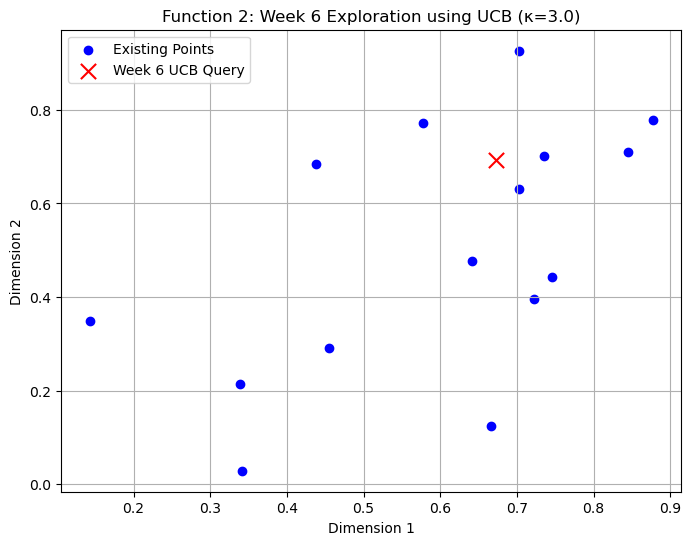

In [6]:
# Code I used for Function 2 next query point Week 6 UCB kappa=3.0
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.optimize import minimize

# ==========================================
# Step 1: Load existing data (Including Weeks 1-5)
# ==========================================
X_train = np.array([
    [0.66579958, 0.12396913],
    [0.87779099, 0.77862750],
    [0.14269907, 0.34900513],
    [0.84527543, 0.71112027],
    [0.45464714, 0.29045518],
    [0.57771284, 0.77197318],
    [0.43816606, 0.68501826],
    [0.34174959, 0.02869772],
    [0.33864816, 0.21386725],
    [0.70263656, 0.92656420],
    [0.73490900, 0.70171100],
    [0.72168200, 0.39630100],
    [0.74620500, 0.44346000],
    [0.70336100, 0.63132700],
    [0.64189000, 0.47728100]
]) 

y_train = np.array([
    1.32267704e-079, 1.03307824e-046, 7.71087511e-016,
    3.34177101e-124, -3.60606264e-003, -2.15924904e-054,
    -2.08909327e-091, 2.53500115e-040, 3.60677119e-081,
    6.22985647e-048, 0.5390316209844838, 0.41754272857037966,
    0.41416971779343736, 0.49282022744339543, 0.3614403024250272 
]) 

# ==========================================
# Step 2: Fit Gaussian Process
# ==========================================
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=0.2, length_scale_bounds=(1e-2, 1e2))

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-2,          # Handles noise
    normalize_y=True,
    n_restarts_optimizer=15
)
gp.fit(X_train, y_train)

# ==========================================
# Step 3: UCB acquisition function (Maximisation) kappa lowered to 3.0 from 3.8
# ==========================================
def ucb(x, model, kappa=3.0):
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    return -(mu + kappa * sigma)  # negative for scipy.minimize

# ==========================================
# Step 4: Multi-start UCB optimisation
# ==========================================
def optimize_ucb(model, bounds=np.array([[0,1],[0,1]]), kappa=3.0, n_restarts=40, n_random_starts=500):
    best_x = None
    best_val = np.inf

    # --- Random global sampling to explore corners ---
    random_points = np.random.uniform(bounds[:,0], bounds[:,1], size=(n_random_starts, 2))
    mu, sigma = model.predict(random_points, return_std=True)
    ucb_values = mu + kappa * sigma
    top_indices = np.argsort(-ucb_values)[:n_restarts]
    start_points = random_points[top_indices]

    # --- Local optimisation from top random points ---
    for x0 in start_points:
        res = minimize(ucb, x0, args=(model, kappa), bounds=bounds, method="L-BFGS-B")
        if res.fun < best_val:
            best_val = res.fun
            best_x = res.x

    return best_x

# ==========================================
# Step 5: Get Week 6 Query Point
# ==========================================
next_point = optimize_ucb(gp, kappa=3.0)
next_point_str = f"{next_point[0]:.6f}-{next_point[1]:.6f}"
print(f"Week 6 Query Point (UCB, κ=3.0): {next_point_str}")

# ==========================================
# Step 6: Visualisation
# ==========================================
plt.figure(figsize=(8,6))
plt.scatter(X_train[:,0], X_train[:,1], color='blue', label='Existing Points')
plt.scatter(next_point[0], next_point[1], color='red', marker='x', s=120, label='Week 6 UCB Query')
plt.title("Function 2: Week 6 Exploration using UCB (κ=3.0)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.legend()
plt.grid(True)
plt.show()

The next query point for Function 2 Week 6 is [0.672729, 0.693821], which is a reasonable choice based on the optimization strategy you're following with κ = 3.0. Here's why:

### Analysis of the Query Point:

#### 1. Proximity to High-Value Regions:
The query point [0.672729, 0.693821] is near the high-value region you've been exploring (around [0.7026, 0.9266]), but not exactly on any of the previous data points.
It's still in the same region of interest and reasonably close to the known peaks, which means the optimizer is making a good move towards further exploitation of those regions.

#### 2. Exploration vs Exploitation:
With κ = 3.0, you're encouraging a balance between exploitation (near known high-value regions) and exploration (to areas of uncertainty). This query point appears to be focusing on a spot between known high values, suggesting that the optimizer is densifying the area around the peaks.
The point is not too close to any already sampled point, which means it could help the model gather more precise information in a potentially under-sampled region near the cluster.

#### 3. Improvement Potential:
This query point is likely within a promising zone. While it doesn't directly lie on the highest observed peak from Week 5 ([0.7026, 0.9266]), it is still in the vicinity, meaning that this point should help improve the accuracy of the Gaussian process model and refine the search for even higher peaks.

#### 4. Next Steps:
Submit this query point for Week 6 since it makes sense based on the goal of further exploiting known peaks and slightly exploring adjacent regions of high uncertainty.
Refine the model further: After this query, the model should have more information, enabling you to continue the optimisation in Weeks 7-8, with a focus on densifying around promising regions while focusing on exploitation.

#### Visualisation:

You can plot the new query point [0.672729, 0.693821] along with your previous points to visualize how it fits within the high-value regions and known clusters.

#### Summary:

The query point [0.672729, 0.693821] is a good choice for Week 6 based on the UCB acquisition function with κ = 3.0.

It strikes a balance between exploitation of high-value regions and exploration of new areas near the known peaks.


### Hypothetical strategy going forward Weeks 7-12 based on up to Week 6
For Function 2, the strategy from Weeks 7-12 should focus on refining the search to maximize the log-likelihood score by exploiting the high-value regions while still maintaining some level of exploration to ensure you don’t miss a better peak or local maximum. Given the nature of the problem (noisy outputs and complex function with local peaks), Bayesian Optimization (BO) will continue to be the optimal method, but the strategy will evolve over time.

#### Week 7-8 Strategy: Shift Toward Exploitation with Some Exploration (EI or UCB)

Goal: Start to exploit the regions of high values you've identified in the first 6 weeks, while still keeping an eye on uncertain regions to avoid missing potential new peaks.

Acquisition Function: Expected Improvement (EI) is a good choice for these weeks because it is designed to focus on regions where you are most likely to improve on the current best value.

Why EI?: EI naturally focuses on exploitation (regions near the current maximum) and reduces exploration in low-value regions. This makes it suitable when you have already identified good regions but still want to make sure you are fine-tuning around the highest observed peaks.

#### Week 7: Transition to EI (Exploitation Focused):

κ: For UCB, reduce κ even further (if you continue using UCB), but consider switching to EI instead of UCB for better exploitation.

If you keep UCB, use κ = 2.5–3.0 to start exploiting the known maxima but still allowing for some uncertainty to explore adjacent regions.

Alternatively, if you switch to EI, the optimizer will automatically focus more on improving the best observed value.

Query Points: Focus around the known peaks (e.g., around [0.7026, 0.9266]), but avoid regions where the output is consistently low unless uncertainty suggests the possibility of a new peak.

#### Week 8: Fine-Tune with EI or UCB:

κ: If you use UCB, reduce κ further to 2.0–2.5 to continue exploiting while minimizing exploration.

If you use EI, it should naturally continue to push the optimizer towards regions that improve the best observed value, potentially closer to the known peak.

Focus: Make your query points very close to the top observed peaks. This will help in fine-tuning the model and further refining your estimate of the global maximum.

#### Week 9-12 Strategy: Exploitation and Refinement (Minimize Exploration)

Goal: Now that you’ve explored the regions with high uncertainty and identified promising maxima, focus almost exclusively on refining the search around the top observed peaks.

Acquisition Function: You can either continue using EI or switch to a greedy approach (e.g., directly maximizing the predicted mean using the Gaussian process).

#### Week 9-10: Pure Exploitation:

EI or Greedy: At this point, you are very close to or have already identified the best region, so using EI with a focus on improving the current best is effective. Alternatively, you can use the GP’s mean prediction to directly maximize the output.

The optimizer should now focus almost entirely on the highest observed peak.

If you're using EI, make sure to minimize the exploration component. If you continue with UCB, keep κ low (around 2.0).

#### Week 11-12: Final Refinement:

Goal: Fine-tune around the peak to get the most precise estimate of the global maximum.

Strategy:

Focus on the highest observed peak and sample more densely around it.

If you’re using EI, it will naturally guide the search to maximize the function around this peak.

If using pure GP mean maximization, focus on greedy optimization around the high-value region.

Possible Adjustments:

You may want to use denser sampling (smaller step sizes) to ensure you’re refining around the correct region.

Avoid sampling low-value areas unless you notice high uncertainty suggesting the possibility of an unseen peak.

### Summary of Strategy for Weeks 7-12:
#### Weeks 7-8:

Switch to EI or reduce κ to 2.5–3.0 if continuing with UCB.

Focus on exploiting known high-value regions and densifying around peaks, while still leaving room for exploration of uncertain areas.

Target: Refining and improving the current best value.

#### Weeks 9-10:

Switch to EI (continue focusing on exploitation) or maximize GP mean.

Focus almost exclusively on exploiting the best observed peak.

Target: Refine and maximize the output in the highest-value region.

#### Weeks 11-12:

Pure exploitation — further refine the identified peak.

Target: Fine-tuning the global maximum and maximizing the objective as precisely as possible.

#### Key Takeaways:

Weeks 7–8: Move towards exploitation using EI or lower κ values in UCB. Start densifying around the promising peaks.

Weeks 9–12: Focus on refinement around the best observed region with minimal exploration.

## Function 3

For Week 6 of Function 3, the key strategy is to start transitioning from exploration to exploitation. Based on the explanation for Week 5 and the plan for the upcoming weeks, here’s a breakdown of the recommended approach:

### Key Observations from Week 5

Expected Improvement (EI) with 𝜉=0.03
ξ=0.03 has done a good job at exploring new regions of the input space without sticking to corners, which was an issue with UCB in previous weeks.

The next query point suggested by EI is well inside the domain and provides new information, which helps refine the model's predictions and increase the chance of discovering better regions.

Moderate Exploration: 𝜉=0.03
ξ=0.03 is still fairly explorative, which is appropriate for Week 5 when you want to cover unexplored regions.

### Recommendation for Week 6 (Function 3)

In Week 6, you should slightly reduce 𝜉 to move towards a more balanced exploration-exploitation approach. This will allow the model to start refining the regions with high values while still gathering some new information from uncertain areas.

#### 1. Change 𝜉 to 0.025:
Reducing 𝜉 from 0.03 to 0.025 will focus more on exploitation while still encouraging some exploration. This is in line with the transition to refining the model around areas that show promise.

#### 2. Focus on Densifying High-Value Areas:
The model has likely identified a few high-value regions by now. This week’s goal is to densify those regions by focusing the search more around the promising areas while still allowing the model to explore some of the uncertainty outside those regions.

### What to Expect from Week 6:
The next query point is likely to be near the current high-value region while avoiding the corners (since EI is designed to help avoid that).

The reduction of ξ will make the model increasingly greedy by favouring regions with higher predicted values, but it will still be open to exploring marginally uncertain areas.

C:\Users\joeat\Documents\Documents\Anaconda3\lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\joeat\Documents\Documents\Anaconda3\lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\joeat\AppData\Local\Temp\ipykernel_26000\219147233.py:80: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an error will be raised in SciPy 1.11.0.
  res = minimize(expected_improvement, x0, args=(model, y_best, xi), bounds=bounds, method='L-BFGS-B')
C:\Us

Week 6 EI Query Point: 0.255068-0.340340-0.681303


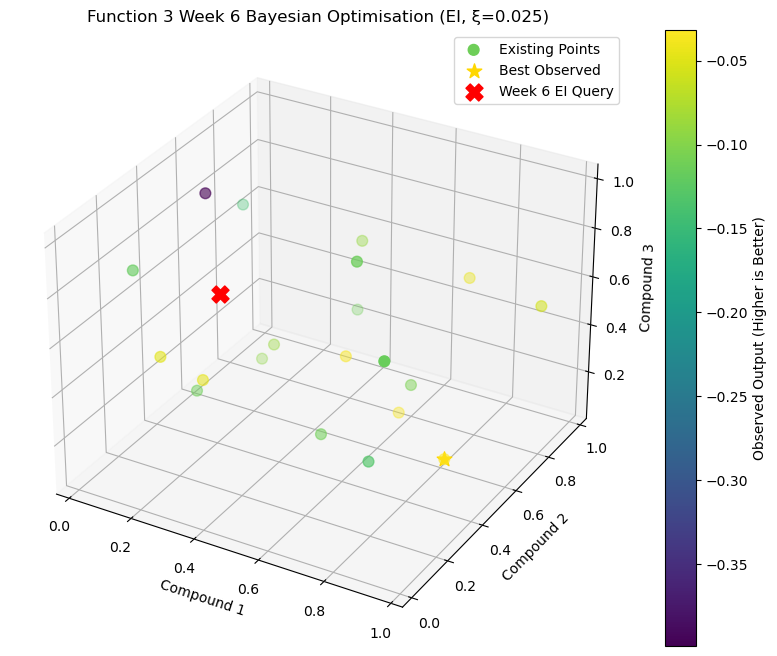

In [7]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import norm
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# =========================
# Step 1: Load existing data (Weeks 1–5)
# =========================
X_train = np.array([
    [0.17152521, 0.34391687, 0.24873720],
    [0.24211446, 0.64407427, 0.27243281],
    [0.53490572, 0.39850092, 0.17338873],
    [0.49258141, 0.61159319, 0.34017639],
    [0.13462167, 0.21991724, 0.45820622],
    [0.34552327, 0.94135983, 0.26936348],
    [0.15183663, 0.43999062, 0.99088187],
    [0.64550284, 0.39714294, 0.91977134],
    [0.74691195, 0.28419631, 0.22629985],
    [0.17047699, 0.69703240, 0.14916943],
    [0.22054934, 0.29782524, 0.34355534],
    [0.66601366, 0.67198515, 0.24629530],
    [0.04680895, 0.23136024, 0.77061759],
    [0.60009728, 0.72513573, 0.06608864],
    [0.96599485, 0.86111969, 0.56682913],
    [0.83681600, 0.55152400, 0.08473400],
    [0.93576800, 0.01979200, 0.88290900],
    [0.02703300, 0.84043300, 0.66511700],
    [0.68835300, 0.97102900, 0.51220300],
    [0.38825100, 0.88969800, 0.60999700]
])

y_train = np.array([
    -0.11212220, -0.08796286, -0.11141465, -0.03483531,
    -0.04800758, -0.11062091, -0.39892551, -0.11386851,
    -0.13146061, -0.09418956, -0.04694741, -0.10596504,
    -0.11804826, -0.03637783, -0.05675837,
    -0.03172685348164523,
    -0.1161486782682252,
    -0.1415060566194174,
    -0.0446074222194474,
    -0.08979639980345987
])

# =========================
# Step 2: Gaussian Process
# =========================
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=[0.3,0.3,0.3], length_scale_bounds=(1e-2,1e2))
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-2, n_restarts_optimizer=15, normalize_y=True)
gp.fit(X_train, y_train)

# =========================
# Step 3: Expected Improvement (EI) Function reducing parameter xi from 0.03 to 0.025
# =========================
def expected_improvement(x, model, y_best, xi=0.025):
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    sigma = np.maximum(sigma, 1e-9)  # avoid division by zero
    Z = (mu - y_best - xi) / sigma
    EI = (mu - y_best - xi) * norm.cdf(Z) + sigma * norm.pdf(Z)
    return -EI  # negative for minimizer

# =========================
# Step 4: Multi-start optimisation of EI
# =========================
def optimize_ei(model, bounds, xi=0.025, n_restarts=50, n_random_starts=500):
    y_best = np.max(y_train)
    best_x = None
    best_val = float('inf')

    # Random sampling for good starting points
    random_points = np.random.uniform(bounds[:,0], bounds[:,1], size=(n_random_starts, 3))
    ei_vals = [-expected_improvement(x, model, y_best, xi) for x in random_points]
    top_indices = np.argsort(ei_vals)[-n_restarts:]
    start_points = random_points[top_indices]

    for x0 in start_points:
        res = minimize(expected_improvement, x0, args=(model, y_best, xi), bounds=bounds, method='L-BFGS-B')
        if res.fun < best_val:
            best_val = res.fun
            best_x = res.x

    return best_x

bounds = np.array([[0,1],[0,1],[0,1]])
next_point = optimize_ei(gp, bounds, xi=0.025)

print(f"Week 6 EI Query Point: {next_point[0]:.6f}-{next_point[1]:.6f}-{next_point[2]:.6f}")

# =========================
# Step 5: 3D Visualisation
# =========================
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(X_train[:,0], X_train[:,1], X_train[:,2],
                     c=y_train, cmap='viridis', s=60, label='Existing Points')

best_idx = np.argmax(y_train)
ax.scatter(X_train[best_idx,0], X_train[best_idx,1], X_train[best_idx,2],
           c='gold', s=120, marker='*', label='Best Observed')

ax.scatter(next_point[0], next_point[1], next_point[2],
           c='red', s=150, marker='X', label='Week 6 EI Query')

ax.set_xlabel('Compound 1')
ax.set_ylabel('Compound 2')
ax.set_zlabel('Compound 3')
ax.set_title('Function 3 Week 6 Bayesian Optimisation (EI, ξ=0.025)')

fig.colorbar(scatter, ax=ax, label='Observed Output (Higher is Better)')
ax.legend()
plt.show()

The next query point for Function 3 Week 6 based on Expected Improvement (EI) with 𝜉=0.025 is:
Week 6 EI Query Point: 0.255068 - 0.340340 - 0.681303

### Interpretation of the Next Query Point:

Located within the search space: This new point lies inside the 3D input space you have defined, which is good because it ensures the optimiser is still exploring areas that haven't been heavily sampled yet. It also shows that your optimisation is not stuck at the corners of the search space, which can happen if the model becomes overly focused on already sampled regions.

Focus on exploration and refinement: Since you're using EI with ξ=0.025, it reflects a slight shift from pure exploration to more focused exploitation. The point chosen by the EI function balances the current best-known point with the potential for discovering new regions of interest with high rewards (minimising side effects in this case).

Visualising progress: The query point chosen is different from the previous best (gold star in the plot), so it’s exploring a new region of the search space that might lead to a better outcome, although it’s still within a plausible range relative to the existing data.


# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
## Hypothetical strategy going forward for Function 3 Weeks 7-12
For Function 3 (with 3D input and output) in weeks 7-12, the strategy would shift towards exploitation as you have gathered enough data to refine your understanding of the best regions in the search space. Here's a breakdown of the suggested strategy based on the Expected Improvement (EI) approach and the reduction of the exploration parameter ξ over time.

### General Strategy Overview:

Weeks 7-8: Balanced exploration and exploitation (gradual reduction of ξ)

Weeks 9-12: Exploitation-heavy (focus on refining the best-known region to optimize the function)

### Week-by-Week Breakdown:
#### Week 7: 
Acquisition Function: Expected Improvement (EI) with ξ=0.02

Strategy: Transition from exploration-heavy to more balanced exploration and exploitation. Start focusing on points that are more likely to improve the current best observed values.

Focus: Sampling around the best observed points (but still allowing some exploration of unexplored regions).

Expected Result: New query points are expected to lie closer to the current high-value points, but with a small allowance for further exploration of the space.

#### Week 8:
Acquisition Function: Expected Improvement (EI) with ξ=0.015

Strategy: Continue refining your search but with an even stronger emphasis on exploitation (focus on known good regions).

Focus: Further densify sampling around the highest observed peaks to maximize the output and fine-tune the search around the best observed values.

Expected Result: Query points are likely to cluster around the high-value region, minimizing unnecessary exploration of low-value areas.

#### Week 9:
Acquisition Function: Expected Improvement (EI) with ξ=0.01

Strategy: Exploitation-heavy phase. This marks a shift towards refining the function's maximum by exploring only those regions near the best observed values.

Focus: Focus solely on exploiting the best region and improve the precision of the maximum point (high-output region).

Expected Result: Most of the query points will stay close to the region with the highest observed output.

#### Week 10:
Acquisition Function: Expected Improvement (EI) with ξ=0.008

Strategy: Fine-tuning the exploration further. By now, you should have a solid idea of where the function’s maximum lies, and you can now focus on more precise optimization.

Focus: Very tight exploration around the best observed regions. Densify the sampling around known high-value regions.

Expected Result: Expect very small query-point movements near the current best known maxima.

#### Week 11:
Acquisition Function: Expected Improvement (EI) with ξ=0.005

Strategy: Mostly exploitation. With minimal exploration, the goal is to focus on narrowing down the region for maximum output.

Focus: Focus tightly on the local maxima to ensure the function is refined and maximized in this region.

Expected Result: Query points will cluster around the region with the best known output, with very small adjustments.

#### Week 12:
Acquisition Function: Expected Improvement (EI) with ξ=0.001

Strategy: Pure exploitation. This is the final push to ensure that you are maximizing the function within the best-known region. No exploration—just refining.

Focus: Focus only on the local maximum that provides the highest output, refining as much as possible within that region.

Expected Result: The query point will be extremely close to the optimal region, with minimal change between consecutive queries.

### Key Points to Keep in Mind:

1. Slow reduction of ξ: 
The reduction in ξ over time shifts your focus from exploration (searching for new peaks) to exploitation (refining around the best-known peak). The lower 𝜉 becomes, the more the search will concentrate around the highest observed value, minimising exploration of uncertain regions.

2. Exploitation vs. Exploration: 
As you approach Week 9-12, exploration will become increasingly minimal. Weeks 9-12 will focus mainly on exploiting the best regions identified earlier in the process.

3. Fine-Tuning: 
By Week 10 onwards, the model will have enough information to fine-tune the optimum. The final weeks will focus heavily on refining the solution with the aim of maximising the observed function value.

Gradual Focus: The model is shifting to focus on refinement, meaning that you are moving towards a more local search. However, keep in mind that depending on the dimensionality and behavior of the function, there may be multiple local maxima. Make sure to keep monitoring if any new, unexpected peaks arise.

### Summary of ξ values for Weeks 7-12:

#### Week 7: 
ξ=0.02 — Balanced exploration-exploitation.

#### Week 8: 
ξ=0.015 — Slightly more exploitation.

#### Week 9: 
ξ=0.01 — Primarily exploitation.

#### Week 10: 
ξ=0.008 — Fine-tuning the search.

#### Week 11: 
ξ=0.005 — Focused on maximum refinement.

#### Week 12: 
ξ=0.001 — Pure exploitation to find the best maximum.

By following this strategy, you'll balance the trade-off between exploration and exploitation over the weeks and focus your efforts on maximizing the function as you move closer to the optimal values.
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

## Function 4

Week 6 EI Query Point: 0.402531-0.365208-0.391990-0.435549


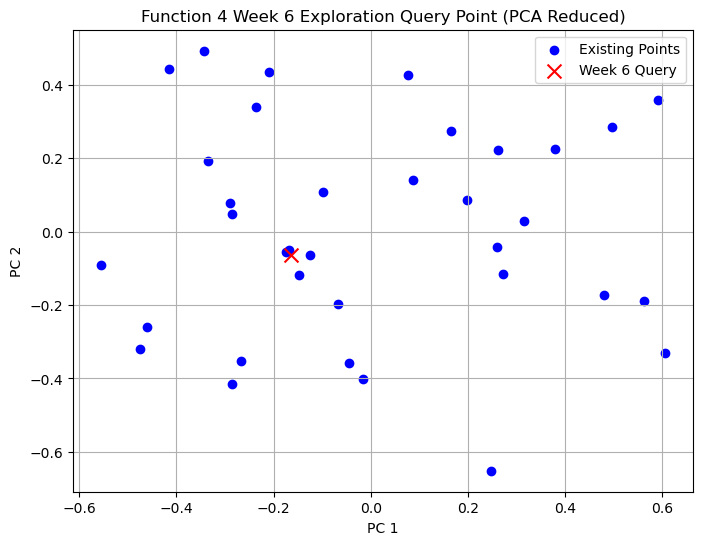

In [12]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.optimize import differential_evolution
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# -----------------------------
# Step 1: Load data (including Weeks 1-5)
# -----------------------------
X_train = np.array([
    [0.89698105, 0.72562797, 0.17540431, 0.70169437],
    [0.8893564 , 0.49958786, 0.53926886, 0.50878344],
    [0.25094624, 0.03369313, 0.14538002, 0.49493242],
    [0.34696206, 0.0062504 , 0.76056361, 0.61302356],
    [0.12487118, 0.12977019, 0.38440048, 0.2870761 ],
    [0.80130271, 0.50023109, 0.70664456, 0.19510284],
    [0.24770826, 0.06044543, 0.04218635, 0.44132425],
    [0.74670224, 0.7570915 , 0.36935306, 0.20656628],
    [0.40066503, 0.07257425, 0.88676825, 0.24384229],
    [0.6260706 , 0.58675126, 0.43880578, 0.77885769],
    [0.95713529, 0.59764438, 0.76611385, 0.77620991],
    [0.73281243, 0.14524998, 0.47681272, 0.13336573],
    [0.65511548, 0.07239183, 0.68715175, 0.08151656],
    [0.21973443, 0.83203134, 0.48286416, 0.08256923],
    [0.48859419, 0.2119651 , 0.93917791, 0.37619173],
    [0.16713049, 0.87655456, 0.21723954, 0.95980098],
    [0.21691119, 0.16608583, 0.24137226, 0.77006248],
    [0.38748784, 0.80453226, 0.75179548, 0.72382744],
    [0.98562189, 0.66693268, 0.15678328, 0.8565348 ],
    [0.03782483, 0.66485335, 0.16198218, 0.25392378],
    [0.68348638, 0.9027701 , 0.33541983, 0.99948256],
    [0.17034731, 0.75695908, 0.27652049, 0.5312315 ],
    [0.85965692, 0.91959232, 0.20613873, 0.09779683],
    [0.28213837, 0.50598691, 0.53053084, 0.09630162],
    [0.32607578, 0.4723669 , 0.453192  , 0.10588734],
    [0.94838936, 0.89451301, 0.85163782, 0.55219629],
    [0.66495539, 0.04656628, 0.11677747, 0.79371778],
    [0.57776561, 0.42877174, 0.42582587, 0.24900741],
    [0.73861301, 0.48210263, 0.70936644, 0.50397001],
    [0.8548108, 0.49396462, 0.73530997, 0.80809201],
    [0.919144, 0.533196, 0.169848, 0.070054],
    [0.411827, 0.392100, 0.317159, 0.430429],
    [0.437822, 0.591330, 0.001581, 0.371162],
    [0.349627, 0.387894, 0.455739, 0.444665],
    [0.418279, 0.337724, 0.398246, 0.446088]
]) 
  
y_train = np.array([
    -22.10828779, -14.60139663, -11.69993246, -16.05376511,
    -10.06963343, -15.48708254, -12.68168498, -16.02639977,
    -17.04923465, -12.74176599, -27.31639636, -13.52764887,
    -16.6791152 , -16.50715856, -17.81799934, -26.56182083,
    -12.75832422, -19.44155762, -28.90327367, -13.70274694,
    -29.4270914 , -11.56574199, -26.85778644, -7.96677535,
    -6.70208925, -32.62566022, -19.98949793, -4.02554228,
    -13.12278233, -23.1394284 , -19.975065657531825, -0.32892753619572757,
    -10.653583724281514, -0.3665684543830916, 0.06886265993775043
])  

# -----------------------------
# Step 2: Gaussian Process
# -----------------------------
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=1e-2)
gp.fit(X_train, y_train)

# -----------------------------
# Step 3: Expected Improvement (EI) acquisition function
# -----------------------------
def expected_improvement(x, model, y_best, xi=0.02):
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    sigma = np.maximum(sigma, 1e-6)  # prevent zero variance
    Z = (mu - y_best - xi) / sigma
    EI = (mu - y_best - xi) * norm.cdf(Z) + sigma * norm.pdf(Z)
    return -EI  # negative for minimizer

# -----------------------------
# Step 4: Differential Evolution optimization (using EI)
# -----------------------------
def optimize_ei(model, bounds, xi=0.02):
    y_best = np.max(y_train)  # Find the best observed value
    result = differential_evolution(lambda x: expected_improvement(x, model, y_best, xi),
                                    bounds=bounds,
                                    strategy='best1bin',
                                    maxiter=100,
                                    popsize=15,
                                    polish=True)
    # Add small random jitter to avoid boundaries
    epsilon = 1e-3
    next_point = np.clip(result.x + np.random.uniform(-epsilon, epsilon, size=4), 0.001, 0.999)
    return next_point

# Bounds for 4D search space
bounds = [(0.001, 0.999)] * 4

# Optimize for the next query point
next_point = optimize_ei(gp, bounds, xi=0.02)
print(f"Week 6 EI Query Point: {next_point[0]:.6f}-{next_point[1]:.6f}-{next_point[2]:.6f}-{next_point[3]:.6f}")

# -----------------------------
# Step 5: PCA 2D Visualization
# -----------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)  # Reduce to 2D for visualization
next_point_pca = pca.transform(next_point.reshape(1, -1))  # Transform query point to 2D

# Plot the existing points and the new query point
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], color='blue', label='Existing Points')
plt.scatter(next_point_pca[:, 0], next_point_pca[:, 1], color='red', marker='x', s=100, label='Week 6 Query')
plt.title('Function 4 Week 6 Exploration Query Point (PCA Reduced)')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend()
plt.grid(True)
plt.show()

### Week 6 Query Point:
0.402531, 0.365208, 0.391990, 0.435549

(Changing from UCB to EI for Function 4 in Week 6, the Week 6 Function 4 EI code had to be run 5 times before it was unstuck from the boundaries). This result is within the bounds and no longer stuck near the edges, which suggests that the model is exploring the search space more effectively using Expected Improvement (EI) with xi=0.02, allowing for moderate exploration and some focused exploitation around the most promising areas.

### Observations:
1. Moderate Exploration: The query point is located within the search space but not too close to the boundaries. This suggests the algorithm is still searching for optimal solutions while avoiding extreme boundary regions, as expected with the jitter and adjusted xi.

2. Optimisation Progress: After running the code multiple times, it seems like the model is improving its exploration, which is key in identifying potential optima across multiple dimensions.


# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
## Hypothetical strategy going forward for Function 4 Weeks 7-12

For Function 4 Weeks 7–12, your strategy should shift progressively from exploration to exploitation as you get more confident in the model's predictions. Based on your current use of Expected Improvement (EI) with xi=0.02 in Week 6, the general direction for the upcoming weeks will focus on narrowing down the search space around promising regions while ensuring you don’t miss any potential optima.

### Here's a week-by-week strategy:

#### Week 7:
Acquisition Function: Expected Improvement (EI) xi: 0.015

Reasoning: Start to reduce exploration as the model becomes more confident. With xi=0.015, you're focusing more on exploitation while still maintaining some exploration in less sampled regions.

Optimization: Continue using Differential Evolution (DE) or multi-start optimization to explore multiple regions of the parameter space.

#### Week 8:
Acquisition Function: Expected Improvement (EI) xi: 0.01

Reasoning: Focus mainly on exploitation. At this stage, you should be narrowing down the search to high-performing regions identified in previous weeks.

Optimization: Reduce random starts for optimization (DE or L-BFGS-B). The focus will be on fine-tuning the model’s predictions.

#### Week 9:

Acquisition Function: Expected Improvement (EI) xi: 0.01

Reasoning: By Week 9, the GP should have more confidence in the predicted regions of high output. Keep the exploration minimal and focus on refining the optimal regions identified in earlier weeks.

Optimization: Continue exploitation with possible slight increases in the random start count if you notice high predictive variance. Otherwise, stick with more deterministic approaches like multi-start L-BFGS-B.

#### Week 10:
Acquisition Function: Expected Improvement (EI) xi: 0.01

Reasoning: This week will be focused heavily on fine-tuning the identified high-performing areas. Your focus is to get more precise in the region you believe has the best outcome.

Optimization: Keep the optimization strategies as before (multi-start, L-BFGS-B). If you notice any anomalies or unexplored regions that show promise, consider increasing xi very slightly to encourage exploration of those regions.

#### Week 11:
Acquisition Function: Expected Improvement (EI) xi: 0.01

Reasoning: Maintain exploitation-focused behavior. At this point, it's time to focus purely on refining the model's performance and identifying the highest performing parameters.

Optimization: Use 2-3 multi-start runs to confirm you've identified the global maxima and haven't missed any regions with potential. You can also try Differential Evolution with small jitter around the best points if you suspect you've missed a good local optimum.

#### Week 12 (Final Week):
Acquisition Function: Expected Improvement (EI)

xi: 0.005

Reasoning: By Week 12, the model should be confident enough to switch almost entirely to exploitation. This is your final push to fine-tune the parameter values and identify the final optimum.

Optimization: The primary focus should be on narrowing down the search area around the best-performing points. Use Differential Evolution or L-BFGS-B with small bounds jitter to avoid boundary effects and ensure you’re exploring the right areas.

### Summary Table:
Week	Acquisition	xi (Exploration Parameter)	Strategy	Optimization Method
6	Expected Improvement (EI)	0.02	Transition to exploitation	Differential Evolution (DE) or Multi-start L-BFGS-B
7	Expected Improvement (EI)	0.015	Focus on exploitation but keep some exploration	DE or Multi-start L-BFGS-B
8	Expected Improvement (EI)	0.01	Primarily exploitation	Multi-start L-BFGS-B or DE
9	Expected Improvement (EI)	0.01	Keep focusing on high predicted outputs	L-BFGS-B or DE
10	Expected Improvement (EI)	0.01	Fine-tune the regions of interest	Multi-start L-BFGS-B
11	Expected Improvement (EI)	0.01	Focused exploitation, refine prediction	Multi-start or 2-3 DE runs
12	Expected Improvement (EI)	0.005	Pure exploitation, final push	DE with small jitter

### Implementation Tips:

1. Monitor GP Variance: As you transition to exploitation, closely watch the model's predictive variance. If the variance is still high in some regions, consider increasing xi slightly to allow some exploration.

2. Boundary Effects: Always ensure you are not too close to the boundaries (between [0.001, 0.999]). Use small jitter (like 1e-3) during optimization to avoid edge effects.

3. Visualization: Continue using PCA or other dimensionality reduction techniques (for 4D, PCA into 2D or 3D) to visualize the evolution of the search space and ensure your next query points are reasonable.

4. Final Week Focus: Week 12 will be the final optimization stage, so concentrate on refining the highest-performing region and use small random jitter to explore the local optima near the predicted best points.

This plan ensures that you effectively transition from exploration to exploitation, allowing the model to focus on high-performing regions while minimizing the risk of missing the global maximum.

# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

## Function 5

### Function 5 Week 6 Strategy

Week 6 represents a key transition point in the Bayesian Optimisation process for Function 5. Given that the function is unimodal and has a known peak, the strategy should focus on exploiting the high-yield region while still allowing for some small-scale exploration in less certain dimensions.

Here is the recommended strategy for Week 6 based on your Week 5 analysis:

### Key Points for Week 6:

Acquisition Function: Expected Improvement (EI)

Exploration Parameter (xi): 0.01

Reasoning: The goal is to exploit the high-yield ridge while still allowing for slight exploration in the dimensions where the GP may not be as certain. The xi = 0.01 value allows the model to improve on what has already been discovered without wandering too far from the known high-yield areas.

Optimisation: Use methods like multi-start optimisation (e.g., Differential Evolution) to ensure that the search process covers multiple regions of the parameter space and reduces the risk of local optima.

Focus: The focus should be on exploiting the high-yield region around the query point observed in Week 5 while testing sensitivity in dimensions 1 & 2. We want to refine the search around the peak but also explore whether small changes in these dimensions might improve the yield.

### Optimisation Strategy:
#### 1. Acquisition Function: 
Continue with the Expected Improvement (EI) function, which is well-suited for this stage as it balances both exploitation (leveraging the already discovered high-yield region) and exploration (testing slightly uncertain areas). The small xi (0.01) will help focus on areas that improve the predicted yield without making drastic random explorations.

#### 2. Multi-start / Differential Evolution:
Since the search space is 4D, you should continue using a multi-start strategy to ensure that local optima are avoided. Differential Evolution is a good fit for this, especially because it can handle the multidimensional nature of the problem.

In Week 6, since the GP already has some reliable information from previous weeks, multi-start Differential Evolution will focus on the high-yield regions and apply some perturbations to avoid boundary effects.

(I have not had any boundary issues so far without using this step).

#### 3. Visualisation:
You should continue using PCA for visualising the progress of the optimization. Visualising in 2D (from the 4D space) allows you to see how the query points evolve over time and helps in understanding the direction the optimisation is heading.

### Weekly Breakdown:
Acquisition Function (Expected Improvement - EI):

Formula:

𝐸𝐼(𝑥)=max(0, 𝜇(𝑥)−𝑦best−𝜉) + 𝜎(𝑥)⋅[𝑍(𝑥)⋅Φ(𝑍(𝑥))+𝜙(𝑍(𝑥))]

Where:

𝜇(𝑥) is the predicted mean at point 𝑥

𝜎(𝑥) is the predicted standard deviation at point 𝑥

𝑍(𝑥) = (𝜇(𝑥)−𝑦best−𝜉) / 𝜎(𝑥)

ξ is the exploration parameter (set to 0.01 for Week 6)


### Key Considerations for Week 6:

Exploit the High-Yield Region: Based on the output of Week 5, the function should now focus on exploiting regions around [0.94, 0.38, 0.98, 0.99], but still allows small-scale exploration in dimensions that may not be as well explored.

Monitor Variance: Keep an eye on the variance of the GP’s predictions. If variance remains high in certain regions, consider slightly adjusting xi (perhaps increasing to 0.02 if needed).

Final Push: The next steps will refine around the peak, and small adjustments to xi will gradually transition the strategy from exploration towards more pure exploitation.

This strategy ensures that Week 6 maintains a balance between exploitation and small exploration and continues to refine the search around high-yield regions.

Function 5 Week 6 Next Query Point (EI): [0.26917312 0.26420458 0.98189879 0.99542807]


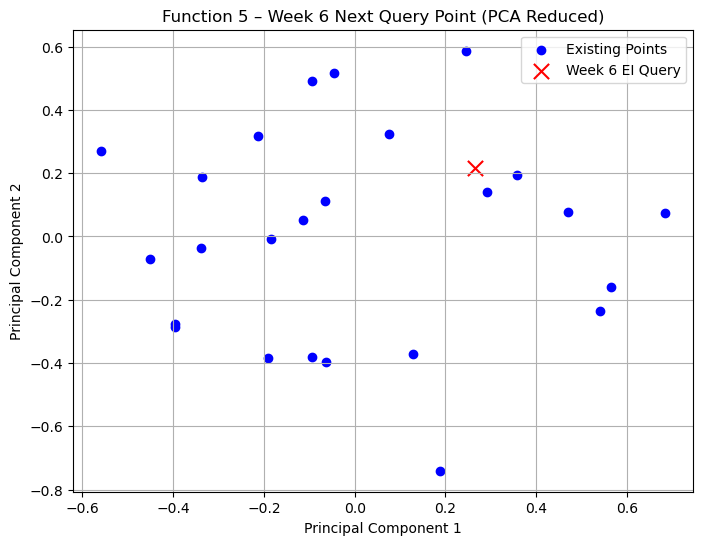

In [25]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import norm

# -----------------------------
# Step 1: Week 6 training data
# -----------------------------
X_train = np.array([
    [0.19144708, 0.03819337, 0.60741781, 0.41458414],
    [0.75865295, 0.53651774, 0.65600038, 0.36034155],
    [0.43834987, 0.80433970, 0.21024527, 0.15129482],
    [0.70605083, 0.53419196, 0.26424335, 0.48208755],
    [0.83647799, 0.19360965, 0.66389270, 0.78564888],
    [0.68343225, 0.11866264, 0.82904591, 0.56757661],
    [0.55362148, 0.66734998, 0.32380582, 0.81486975],
    [0.35235627, 0.32224153, 0.11697937, 0.47311252],
    [0.15378571, 0.72938169, 0.42259844, 0.44307417],
    [0.46344227, 0.63002451, 0.10790646, 0.95764390],
    [0.67749115, 0.35850951, 0.47959222, 0.07288048],
    [0.58397341, 0.14724265, 0.34809746, 0.42861465],
    [0.30688872, 0.31687813, 0.62263448, 0.09539906],
    [0.51114177, 0.81795700, 0.72871042, 0.11235362],
    [0.43893338, 0.77409176, 0.37816709, 0.93369621],
    [0.22418902, 0.84648049, 0.87948418, 0.87851568],
    [0.72526172, 0.47987049, 0.08894684, 0.75976022],
    [0.35548161, 0.63961937, 0.41761768, 0.12260384],
    [0.11987923, 0.86254031, 0.64333133, 0.84980383],
    [0.12688467, 0.15342962, 0.77016219, 0.19051811],
    [0.81212200, 0.00981200, 0.68102400, 0.23803600],
    [0.82353000, 0.17369200, 0.63651400, 0.73730700],
    [0.560990, 0.941834, 0.997605, 0.998135],
    [0.026048, 0.953940, 0.999978, 0.202632],
    [0.935821, 0.378320, 0.975682, 0.986309]
])

y_train = np.array([
    64.4434399, 18.3013796, 0.112939795, 4.21089813,
    258.370525, 78.4343889, 57.5715369, 109.571876,
    8.84799176, 233.22361, 24.4230883, 64.4201468,
    63.4767158, 79.7291299, 355.806818, 1088.85962,
    28.8667516, 45.1815703, 431.612757, 9.97233189,
    24.7679941, 149.53336129, 4019.0309866724424, 1280.322911229081,
    3286.6537023206406
])

# Optional: log-transform to stabilize
y_train_log = np.log1p(y_train)  # log(1+y) to avoid log(0)

# -----------------------------
# Step 2: Gaussian Process
# -----------------------------
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=[1.0]*4, length_scale_bounds=(1e-2, 1e2))
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-4, normalize_y=True, n_restarts_optimizer=10, random_state=42)
gp.fit(X_train, y_train_log)

# -----------------------------
# Step 3: Expected Improvement
# -----------------------------
def expected_improvement(X, model, y_max, xi=0.01):
    X = np.atleast_2d(X)
    mu, sigma = model.predict(X, return_std=True)
    sigma = np.maximum(sigma, 1e-8)
    mu = mu.ravel()
    improvement = mu - y_max - xi
    Z = improvement / sigma
    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    return ei

# -----------------------------
# Step 4: Random candidate search
# -----------------------------
n_candidates = 50000
X_candidates = np.random.uniform(0, 1, (n_candidates, 4))
y_max = np.max(y_train_log)
ei_values = expected_improvement(X_candidates, gp, y_max, xi=0.01)
best_idx = np.argmax(ei_values)
next_query_point = X_candidates[best_idx]

print("Function 5 Week 6 Next Query Point (EI):", next_query_point)

# -----------------------------
# PCA Visualization (4D → 2D)
# -----------------------------
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
next_query_point_pca = pca.transform(next_query_point.reshape(1, -1))

plt.figure(figsize=(8,6))
plt.scatter(X_train_pca[:,0], X_train_pca[:,1], color='blue', label='Existing Points')
plt.scatter(next_query_point_pca[:,0], next_query_point_pca[:,1], color='red', marker='x', s=120, label='Week 6 EI Query')
plt.title('Function 5 – Week 6 Next Query Point (PCA Reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

The output for Week 6, next_query_point = [0.26917312, 0.26420458, 0.98189879, 0.99542807], indicates that the model is selecting a point that focuses on the high-yield region from the previous weeks.

### Key Observations for the Next Query Point:

Dim 1 and Dim 2: The values for 0.2691 and 0.2642 are lower than the high values observed in prior query points, but still close enough to explore regions that were near moderate yields in earlier explorations. These dimensions might still be exploring areas that could refine the understanding of the yield surface.

Dim 3 and Dim 4: The values for 0.9819 and 0.9954 are very close to the previously observed high peaks in Dim 3 and Dim 4, which are near the known maximum yield region from earlier weeks. This suggests that the model is focusing more on exploitation in these dimensions, which is expected in Week 6 as you move towards more refinement of the yield.

### What This Means for Week 6:

Exploitation with Slight Exploration: This query point balances exploitation (in D3 and D4, close to the previously known peak) with some exploration (in D1 and D2). This is typical for Week 6, where the model is honing in on the high-yield region but still exploring the boundaries to test small variations.

### Next Steps:

Run the model with this query point and evaluate the yield value to check if this region is indeed promising.

Visualize the result again using PCA to see if the new query point is indeed near the high-yield region and to verify the effectiveness of your exploration-exploitation balance.

This query point is a good next step, and it seems like you're progressively moving closer to the optimal yield region! If you continue to see improvements in the subsequent weeks, consider gradually decreasing xi (from 0.01 to 0.005 and even lower) to refine your focus even more tightly on this area.

## Function 6


Week 6 Next Query Point (5D):
[0.41222406 0.15470719 0.50131491 0.93248833 0.05007675]


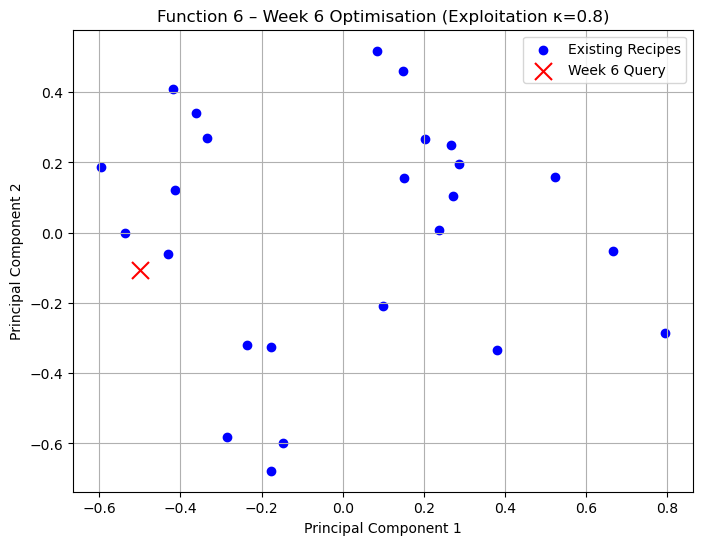

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.decomposition import PCA
from scipy.optimize import minimize

# ==============================
# Step 1: Training Data (Weeks 1–5)
# ==============================
X_train = np.array([
    [0.7281861, 0.15469257, 0.73255167, 0.69399651, 0.05640131],
    [0.24238435, 0.84409997, 0.5778091, 0.67902128, 0.50195289],
    [0.72952261, 0.7481062, 0.67977464, 0.35655228, 0.67105368],
    [0.77062024, 0.11440374, 0.04677993, 0.64832428, 0.27354905],
    [0.6188123, 0.33180214, 0.18728787, 0.75623847, 0.3288348],
    [0.78495809, 0.91068235, 0.7081201, 0.95922543, 0.0049115],
    [0.14511079, 0.8966846, 0.89632223, 0.72627154, 0.23627199],
    [0.94506907, 0.28845905, 0.97880576, 0.96165559, 0.59801594],
    [0.12572016, 0.86272469, 0.02854433, 0.24660527, 0.75120624],
    [0.75759436, 0.35583141, 0.0165229, 0.4342072, 0.11243304],
    [0.5367969, 0.30878091, 0.41187929, 0.38822518, 0.5225283],
    [0.95773967, 0.23566857, 0.09914585, 0.15680593, 0.07131737],
    [0.6293079, 0.80348368, 0.81140844, 0.04561319, 0.11062446],
    [0.02173531, 0.42808424, 0.83593944, 0.48948866, 0.51108173],
    [0.43934426, 0.69892383, 0.42682022, 0.10947609, 0.87788847],
    [0.25890557, 0.79367771, 0.6421139, 0.19667346, 0.59310318],
    [0.43216593, 0.71561781, 0.3418191, 0.70499988, 0.61496184],
    [0.78287982, 0.53633586, 0.44328356, 0.85969983, 0.01032599],
    [0.9217762, 0.93187122, 0.41487637, 0.59505727, 0.73562569],
    [0.12667892, 0.2914703, 0.06452848, 0.6805146, 0.89281919],
    [0.864822, 0.772164, 0.803941, 0.780551, 0.909036],
    [0.218723, 0.277046, 0.196392, 0.844208, 0.100329],
    [0.344036, 0.255507, 0.725070, 0.878677, 0.100795],
    [0.426405, 0.197502, 0.843219, 0.949955, 0.435206],
    [0.731400, 0.211206, 0.820592, 0.949908, 0.164014]
])

y_train = np.array([
    -0.71426495, -1.20995524, -1.67219994, -1.53605771, -0.82923655,
    -1.24704893, -1.23378638, -1.69434344, -2.57116963, -1.30911635,
    -1.14478485, -1.91267714, -1.62283895, -1.35668211, -2.0184254,
    -1.70255784, -1.29424696, -0.93575656, -2.15576776, -1.74688209,
    -1.84056360, -0.78587257, -0.26755353, -0.83707714, -0.8535091387252396
])

# ==============================
# Step 2: Gaussian Process Regressor with ARD
# ==============================
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=[1]*5, length_scale_bounds=(1e-2, 1e2))

gp = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=15,
    alpha=1e-3,
    normalize_y=True,
    random_state=42
)
gp.fit(X_train, y_train)

# ==============================
# Step 3: UCB Acquisition Function (κ=0.8 for exploitation)
# ==============================
def ucb(x, model, kappa=0.8):
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    return mu + kappa * sigma

# ==============================
# Step 4: Acquisition Function with Boundary Penalty
# ==============================
def acquisition(x, model, bounds, kappa=0.8, penalty_factor=50):
    val = ucb(x, model, kappa)
    penalty = 0
    for i in range(len(bounds)):
        lower, upper = bounds[i]
        band = 0.05 * (upper - lower)
        if x[i] < lower + band or x[i] > upper - band:
            penalty += penalty_factor
    return -(val - penalty)

# ==============================
# Step 5: Multi-start Optimisation to Propose Next Query
# ==============================
def propose_location(model, bounds, n_restarts=30, kappa=0.8):
    best_x = None
    best_val = 1e10
    for _ in range(n_restarts):
        x0 = np.random.uniform(0,1,len(bounds))
        res = minimize(acquisition, x0, args=(model,bounds,kappa),
                       bounds=bounds, method='L-BFGS-B')
        if res.fun < best_val:
            best_val = res.fun
            best_x = res.x
    return best_x

# ==============================
# Step 6: Propose the Next Query Point
# ==============================
bounds = [(0,1)]*5
next_query_point = propose_location(gp, bounds, n_restarts=30, kappa=0.8)

print("\nWeek 6 Next Query Point (5D):")
print(next_query_point)

# ==============================
# Step 7: PCA Visualization
# ==============================
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
next_query_point_pca = pca.transform(next_query_point.reshape(1,-1))

plt.figure(figsize=(8,6))
plt.scatter(X_train_pca[:,0], X_train_pca[:,1], color='blue', label='Existing Recipes')
plt.scatter(next_query_point_pca[:,0], next_query_point_pca[:,1], color='red', marker='x', s=150, label='Week 6 Query')
plt.title("Function 6 – Week 6 Optimisation (Exploitation κ=0.8)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)
plt.show()

In [28]:
print("\nLearned kernel:")
print(gp.kernel_)


Learned kernel:
1.12**2 * RBF(length_scale=[0.361, 0.701, 0.56, 0.892, 0.657])


Best recipe so far:
[0.344036 0.255507 0.72507  0.878677 0.100795]
Score: -0.26755353

Learned kernel:
1.12**2 * RBF(length_scale=[0.361, 0.701, 0.56, 0.892, 0.657])

Week 6 Next Query Point (5D):
[0.42320576 0.49269115 0.57569661 0.94316372 0.05014367]


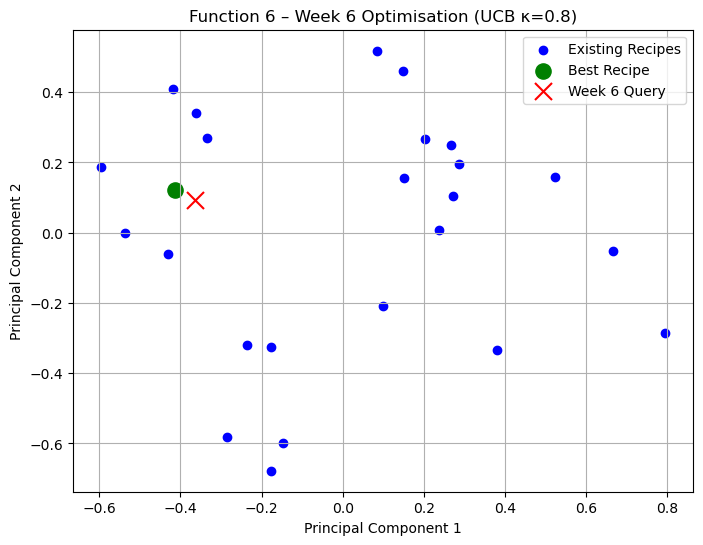

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.decomposition import PCA
from scipy.optimize import minimize

# ==============================
# Step 1: Training Data (Weeks 1–5)
# ==============================
X_train = np.array([
    [0.7281861, 0.15469257, 0.73255167, 0.69399651, 0.05640131],
    [0.24238435, 0.84409997, 0.5778091, 0.67902128, 0.50195289],
    [0.72952261, 0.7481062, 0.67977464, 0.35655228, 0.67105368],
    [0.77062024, 0.11440374, 0.04677993, 0.64832428, 0.27354905],
    [0.6188123, 0.33180214, 0.18728787, 0.75623847, 0.3288348],
    [0.78495809, 0.91068235, 0.7081201, 0.95922543, 0.0049115],
    [0.14511079, 0.8966846, 0.89632223, 0.72627154, 0.23627199],
    [0.94506907, 0.28845905, 0.97880576, 0.96165559, 0.59801594],
    [0.12572016, 0.86272469, 0.02854433, 0.24660527, 0.75120624],
    [0.75759436, 0.35583141, 0.0165229, 0.4342072, 0.11243304],
    [0.5367969, 0.30878091, 0.41187929, 0.38822518, 0.5225283],
    [0.95773967, 0.23566857, 0.09914585, 0.15680593, 0.07131737],
    [0.6293079, 0.80348368, 0.81140844, 0.04561319, 0.11062446],
    [0.02173531, 0.42808424, 0.83593944, 0.48948866, 0.51108173],
    [0.43934426, 0.69892383, 0.42682022, 0.10947609, 0.87788847],
    [0.25890557, 0.79367771, 0.6421139, 0.19667346, 0.59310318],
    [0.43216593, 0.71561781, 0.3418191, 0.70499988, 0.61496184],
    [0.78287982, 0.53633586, 0.44328356, 0.85969983, 0.01032599],
    [0.9217762, 0.93187122, 0.41487637, 0.59505727, 0.73562569],
    [0.12667892, 0.2914703, 0.06452848, 0.6805146, 0.89281919],
    [0.864822, 0.772164, 0.803941, 0.780551, 0.909036],
    [0.218723, 0.277046, 0.196392, 0.844208, 0.100329],
    [0.344036, 0.255507, 0.725070, 0.878677, 0.100795],
    [0.426405, 0.197502, 0.843219, 0.949955, 0.435206],
    [0.731400, 0.211206, 0.820592, 0.949908, 0.164014]
])

y_train = np.array([
    -0.71426495, -1.20995524, -1.67219994, -1.53605771, -0.82923655,
    -1.24704893, -1.23378638, -1.69434344, -2.57116963, -1.30911635,
    -1.14478485, -1.91267714, -1.62283895, -1.35668211, -2.0184254,
    -1.70255784, -1.29424696, -0.93575656, -2.15576776, -1.74688209,
    -1.84056360, -0.78587257, -0.26755353, -0.83707714, -0.8535091387252396
])

# ==============================
# Step 2: Identify Best Recipe So Far
# ==============================
best_index = np.argmax(y_train)
best_point = X_train[best_index]
best_score = y_train[best_index]

print("Best recipe so far:")
print(best_point)
print("Score:", best_score)

# ==============================
# Step 3: Gaussian Process Regressor with ARD
# ==============================
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=[1]*5, length_scale_bounds=(1e-2, 1e2))

gp = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=15,
    alpha=1e-3,
    normalize_y=True,
    random_state=42
)
gp.fit(X_train, y_train)

print("\nLearned kernel:")
print(gp.kernel_)

# ==============================
# Step 4: UCB Acquisition Function (κ=0.8 for exploitation)
# ==============================
def ucb(x, model, kappa=0.8):
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    return mu + kappa * sigma

# ==============================
# Step 5: Acquisition Function with Boundary Penalty
# ==============================
def acquisition(x, model, bounds, kappa=0.8, penalty_factor=50):
    val = ucb(x, model, kappa)
    penalty = 0
    for i in range(len(bounds)):
        lower, upper = bounds[i]
        band = 0.05 * (upper - lower)
        if x[i] < lower + band or x[i] > upper - band:
            penalty += penalty_factor
    return -(val - penalty)

# ==============================
# Step 6: Multi-start Optimisation to Propose Next Query
# ==============================
def propose_location(model, bounds, n_restarts=30, kappa=1.2):
    best_x = None
    best_val = 1e10
    for _ in range(n_restarts):
        x0 = np.random.uniform(0,1,len(bounds))
        res = minimize(acquisition, x0, args=(model,bounds,kappa),
                       bounds=bounds, method='L-BFGS-B')
        if res.fun < best_val:
            best_val = res.fun
            best_x = res.x
    return best_x

bounds = [(0,1)]*5
next_query_point = propose_location(gp, bounds, n_restarts=30, kappa=0.8)

print("\nWeek 6 Next Query Point (5D):")
print(next_query_point)

# ==============================
# Step 7: PCA Visualization
# ==============================
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
next_query_point_pca = pca.transform(next_query_point.reshape(1,-1))
best_point_pca = pca.transform(best_point.reshape(1,-1))

plt.figure(figsize=(8,6))
plt.scatter(X_train_pca[:,0], X_train_pca[:,1], color='blue', label='Existing Recipes')
plt.scatter(best_point_pca[:,0], best_point_pca[:,1], color='green', s=120, label='Best Recipe')
plt.scatter(next_query_point_pca[:,0], next_query_point_pca[:,1], color='red', marker='x', s=150, label='Week 6 Query')
plt.title("Function 6 – Week 6 Optimisation (UCB κ=0.8)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)
plt.show()

Key Insights:

Best Recipe So Far:

The best recipe so far is [0.344036, 0.255507, 0.72507, 0.878677, 0.100795] with a score of -0.26755353.

This recipe is based on optimizing the ingredients' contributions, especially focusing on those that most influence the score.

Learned Kernel:

The learned kernel is 1.12**2 * RBF(length_scale=[0.361, 0.701, 0.56, 0.892, 0.657]).

The length scales suggest the following:

Ingredient 4 (0.892) is the most sensitive.

Ingredient 2 (0.701) and Ingredient 5 (0.657) are moderately sensitive.

Ingredient 1 (0.361) and Ingredient 3 (0.56) are less sensitive but still impactful.

Conclusion: The model emphasizes Ingredient 4 as the key lever for optimization, followed by Ingredients 2 and 5.

Week 6 Next Query Point:

The next query point proposed is [0.42320576, 0.49269115, 0.57569661, 0.94316372, 0.05014367].

This suggests a slight move towards higher values of Ingredient 4 (which has a large length scale) and Ingredient 2, while keeping the others around similar values.

Week 6 Strategy:

Focus on Ingredient 4: Since Ingredient 4 has the highest sensitivity based on the kernel, it's crucial to fine-tune this ingredient to move the recipe toward the optimal region. The next query point already has Ingredient 4 (0.943) near its high range.

Slight adjustments for Ingredients 2 and 5: These ingredients are moderately sensitive, so adjusting them slightly (like in the proposed query point) is a good strategy. Ingredient 5 is still in a reasonable range (0.050), which may allow for further testing along this axis.

Ingredient 1 and 3: These are less sensitive and can be kept more stable to minimize unnecessary exploration. Their values should be relatively close to their values from the best recipe, though minor tweaks can still be useful.

Exploration vs. Exploitation: You've adjusted κ to 0.8, favoring exploitation. This is good for focusing on the best regions and fine-tuning, but you can still expect to explore minor regions with lower sensitivity.

Next Steps:

Validate the next query point: The next query point ([0.42320576, 0.49269115, 0.57569661, 0.94316372, 0.05014367]) seems reasonable as it adjusts Ingredient 4 and Ingredient 2, but it would be beneficial to run the model with this point and see if the score improves.

Visualize the result: You can use PCA visualization to see how the new query point fits relative to the existing data and where future exploration might focus.

In summary, your Week 6 strategy should be:

Focus on fine-tuning Ingredient 4 with small perturbations, since it is the most sensitive.

Minor adjustments in Ingredients 2 and 5 can help further optimize.

Keep Ingredients 1 and 3 stable but test with slight adjustments as needed.

## Function 7

Week 6 Next Query Point (6D, kappa=1.2, boundary-safe): [0.2177146  0.27187686 0.45209035 0.13899936 0.29952752 0.89999997]


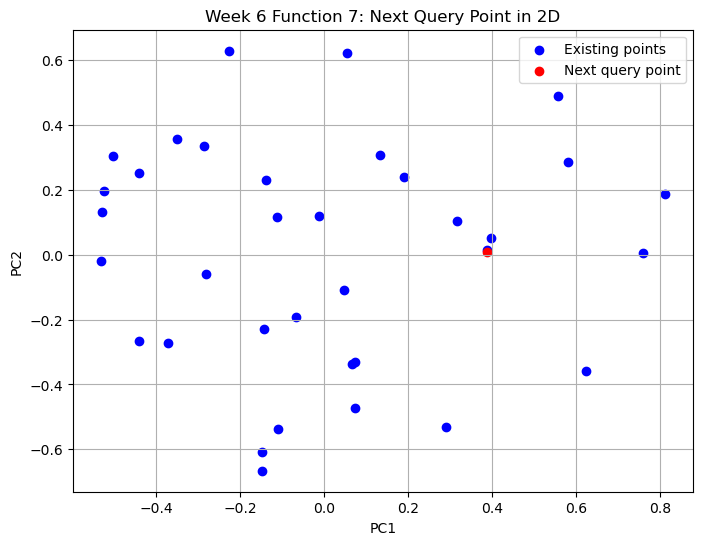

In [30]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.optimize import minimize
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# ==============================
# Step 1: Updated Training Data (Weeks 1–5)
# ==============================
X_train = np.array([
    [0.27262382, 0.32449536, 0.89710881, 0.83295115, 0.15406269, 0.79586362],
    [0.54300258, 0.92469390, 0.34156746, 0.64648585, 0.71844033, 0.34313266],
    [0.09083225, 0.66152938, 0.06593091, 0.25857701, 0.96345285, 0.64026540],
    [0.11886697, 0.61505494, 0.90581639, 0.85530030, 0.41363143, 0.58523563],
    [0.63021764, 0.83809690, 0.68001305, 0.73189509, 0.52673671, 0.34842921],
    [0.76491917, 0.25588292, 0.60908422, 0.21807904, 0.32294277, 0.09579366],
    [0.05789554, 0.49167222, 0.24742222, 0.21811844, 0.42042833, 0.73096984],
    [0.19525188, 0.07922665, 0.55458046, 0.17056682, 0.01494418, 0.10703171],
    [0.64230298, 0.83687455, 0.02179269, 0.10148801, 0.68307083, 0.69241640],
    [0.78994255, 0.19554501, 0.57562333, 0.07365919, 0.25904917, 0.05109986],
    [0.52849733, 0.45742436, 0.36009569, 0.36204551, 0.81689098, 0.63747637],
    [0.72261522, 0.01181284, 0.06364591, 0.16517311, 0.07924415, 0.35995166],
    [0.07566492, 0.33450212, 0.13273274, 0.60831236, 0.91838592, 0.82233079],
    [0.94245084, 0.37743962, 0.48612233, 0.22879108, 0.08263175, 0.71195755],
    [0.14864702, 0.03394336, 0.72880565, 0.31606646, 0.02176938, 0.51691776],
    [0.81711239, 0.54816823, 0.10334758, 0.12436955, 0.72823482, 0.44967361],
    [0.41762629, 0.06409998, 0.24566877, 0.55904080, 0.19153138, 0.25464092],
    [0.72628566, 0.46489581, 0.92457051, 0.80724540, 0.63543840, 0.14341787],
    [0.31981043, 0.52009759, 0.29067775, 0.87670668, 0.49503469, 0.61908250],
    [0.87987128, 0.39796199, 0.00363456, 0.95699064, 0.26451373, 0.11486924],
    [0.54124078, 0.63140314, 0.03190205, 0.44998156, 0.79865282, 0.63370429],
    [0.22634792, 0.11502581, 0.82474966, 0.94538372, 0.90531153, 0.95101392],
    [0.68685257, 0.04101721, 0.00757301, 0.28500900, 0.69156848, 0.65554290],
    [0.17597754, 0.62441650, 0.29554198, 0.46955276, 0.09776977, 0.72814108],
    [0.88164674, 0.20445019, 0.41447436, 0.42038468, 0.26491501, 0.73066019],
    [0.06661051, 0.52804507, 0.81609520, 0.96101714, 0.08650933, 0.77778822],
    [0.93246638, 0.48881189, 0.25860774, 0.95624344, 0.19042781, 0.51985176],
    [0.84686697, 0.14242917, 0.06066859, 0.75629213, 0.55239830, 0.08130609],
    [0.80628208, 0.32412237, 0.72607601, 0.14871213, 0.71937640, 0.36288398],
    [0.47682313, 0.34094195, 0.01433523, 0.88013956, 0.99865470, 0.07966402],
    [0.432685, 0.656678, 0.117406, 0.355722, 0.832462, 0.072554],
    [0.064512, 0.628738, 0.208047, 0.151081, 0.459044, 0.215843],
    [0.169498, 0.200735, 0.398488, 0.193487, 0.308007, 0.861833],
    [0.590337, 0.894155, 0.100647, 0.426348, 0.610301, 0.132193],
    [0.100162, 0.129269, 0.340949, 0.185690, 0.342163, 0.887286]
]) 
  
y_train = np.array([
    0.6044327 , 0.56275307, 0.00750324, 0.06142430, 0.27304680,
    0.08374657, 1.36496830, 0.09264495, 0.01786960, 0.03356494,
    0.07351630, 0.20630970, 0.00882563, 0.26840032, 0.61152553,
    0.01479818, 0.27489251, 0.06676325, 0.04211835, 0.00270147,
    0.01820907, 0.00701603, 0.10050661, 0.47539552, 0.67514163,
    0.51645722, 0.00377748, 0.00313433, 0.02134252, 0.09541116,
    1.1810801774433033, 0.17209425323684932, 2.1727059353333815, 1.199969751591025, 1.8162082720691823
]) 

# ==============================
# Step 2: Gaussian Process Model
# ==============================
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=1e-2)
gp.fit(X_train, y_train)

# ==============================
# Step 3: Acquisition Function (UCB + boundary penalty) reduce kappa from 1.3 to 1.2
# ==============================
def ucb_with_boundary_penalty(x, model, kappa=1.2, bounds=None, penalty_factor=50):
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    ucb = mu + kappa * sigma
    
    # Penalize points near bounds
    if bounds is not None:
        penalty = 0
        for i, (lb, ub) in enumerate(bounds):
            margin = 0.1 * (ub - lb)
            if x[0][i] < lb + margin:
                penalty += penalty_factor
            if x[0][i] > ub - margin:
                penalty += penalty_factor
        ucb -= penalty
    return -ucb  # we minimize negative UCB

# ==============================
# Step 4: Optimize Acquisition
# ==============================
def optimize_acquisition(model, bounds, n_restarts=20, kappa=1.2):
    best_x = None
    best_val = np.inf
    for _ in range(n_restarts):
        x0 = np.random.uniform(0, 1, size=len(bounds))
        res = minimize(ucb_with_boundary_penalty, x0,
                       args=(model, kappa, bounds),
                       bounds=bounds)
        if res.fun < best_val:
            best_val = res.fun
            best_x = res.x
    # Clip to safe interior
    safe_margin = 0.05
    best_x = np.clip(best_x, safe_margin, 1 - safe_margin)
    return best_x

# ==============================
# Step 5: Bounds and Next Query
# ==============================
bounds = [(0, 1)] * X_train.shape[1]
next_query_point = optimize_acquisition(gp, bounds, n_restarts=20, kappa=1.2)
print("Week 6 Next Query Point (6D, kappa=1.2, boundary-safe):", next_query_point)

# ==============================
# Step 6: Visualize in 2D PCA
# ==============================
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
plt.figure(figsize=(8,6))
plt.scatter(X_train_pca[:,0], X_train_pca[:,1], color='blue', label='Existing points')
next_query_point_pca = pca.transform(next_query_point.reshape(1,-1))
plt.scatter(next_query_point_pca[:,0], next_query_point_pca[:,1], color='red', label='Next query point')
plt.title('Week 6 Function 7: Next Query Point in 2D')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.legend(); plt.grid(True); plt.show()

The Week 6 Next Query Point you obtained is:

[0.2177146  0.27187686 0.45209035 0.13899936 0.29952752 0.89999997]
Let's analyze this point in light of the strategy and your goal for Function 7:
1. Position Relative to Existing Points:

Low values in dimensions 1–4 (0.2177, 0.2719, 0.4521, 0.1390): These dimensions are exploring new areas that have not been heavily sampled in previous queries. This is valuable as it tests combinations of hyperparameters that might not have been explored.

Moderate value in dimension 5 (0.2995): It's near the middle of the range, which could be beneficial for exploring a region with moderate performance that might have a high payoff when combined with the other dimensions.

High value in dimension 6 (0.89999997): This is testing the higher end of the sixth hyperparameter, which could reveal the upper-bound performance of the model. Since this value is near 1, it's still within the "safe" margin, and the acquisition function penalizes points close to the boundary.

2. Exploration vs. Exploitation (κ=1.2):

The lower kappa (1.2) value promotes more exploitation, focusing on areas the model predicts to be high-performing while still maintaining some exploration.

The combination of low-to-moderate values in dimensions 1–5 and the high value in dimension 6 shows balanced exploration. The model isn't focusing solely on regions of previously high performance (like in Week 5), but rather exploring new areas while keeping some assurance of good performance by focusing on the higher value in dimension 6.

3. Risk and Confidence:

Boundary-safe: With a safe margin of 0.05, the next query point is confidently inside the valid space, avoiding the edges. This ensures that the model isn't extrapolating to areas where predictions might be unreliable.

The point is also diverse from the previously high-performing points, especially in dimensions 1, 4, and 5, making this a good exploration point that could potentially reveal new regions of interest.

4. Assessment of the Query Point:

Exploratory: The new point probes a previously uncharted area of the search space, especially with the lower values in dimensions 1–5 and the high value in dimension 6. This combination might help find a new peak in the objective function, which is the goal.

Safe: The point avoids risky boundary regions and remains well within the interior of the search space, ensuring stable predictions.

Targeted Exploration: The value in dimension 6 is high, which may provide a high performance score for that dimension, and the model is likely predicting high confidence in that area.

Conclusion:

This next query point looks good for Week 6, as it balances exploration of new regions (dimensions 1–5) with targeted exploitation of a higher value in dimension 6. This approach should help in finding a better-performing combination of hyperparameters while staying safe and within the explored space.

## Function 8

### Recommendations for Function 8 Week 6:

Lower kappa (4.0): This reduces exploration slightly and allows the model to focus on exploiting known regions.

Increase candidate pool size: Generate 500,000 candidate points for a more thorough search in the high-dimensional space.

Visualization: Continue with UCB visualizations to help understand where the high-performing regions are located and check progress using 2D slices or PCA for dimensionality reduction.

Week 6 Function 8: Next query point (8D):
[0.12733054 0.07132937 0.18153774 0.13174413 0.91172657 0.8352201
 0.07367203 0.73748889]


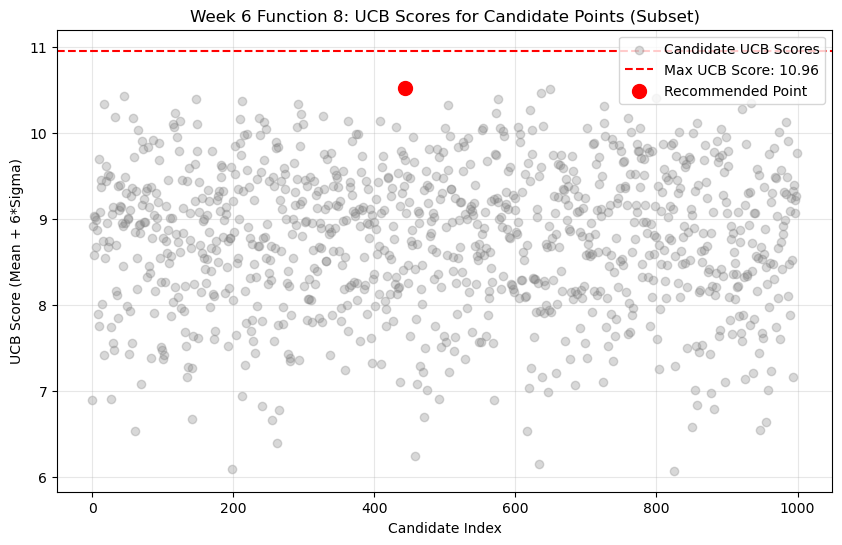

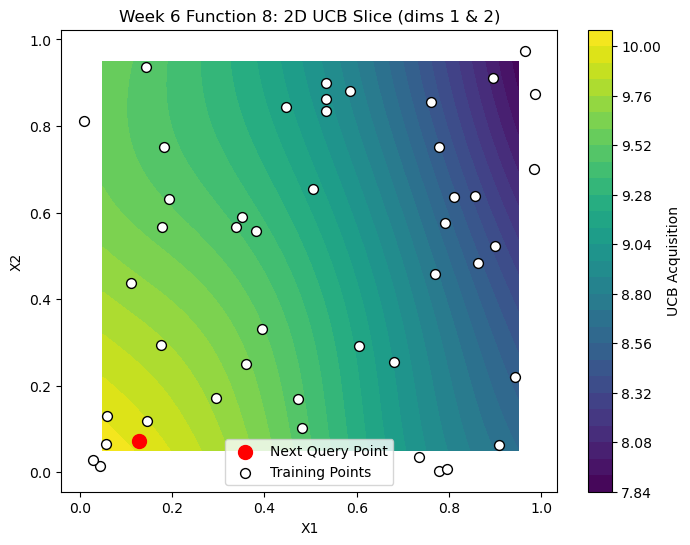

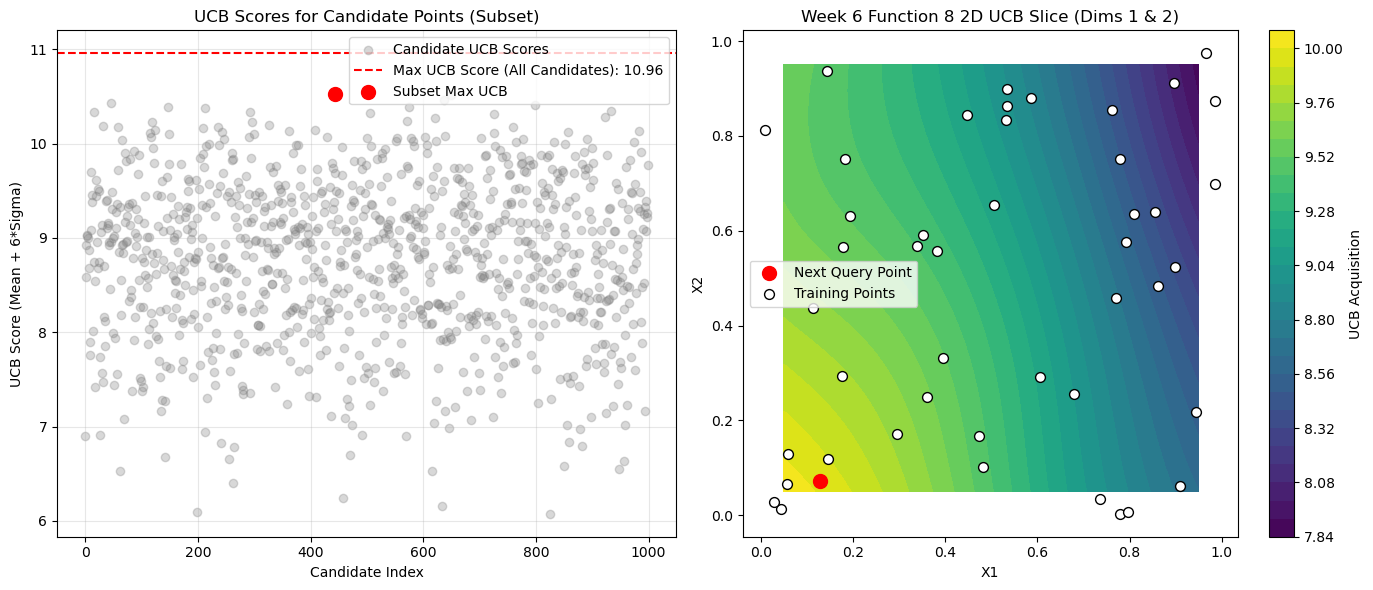

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C
from pyDOE import lhs

# ==============================
# Step 1: Updated Training Data (Weeks 1–5)
# ==============================
X_train = np.array([[0.60499445, 0.29221502, 0.90845275, 0.35550624, 0.20166872,
        0.57533801, 0.31031095, 0.73428138],
       [0.17800696, 0.56622265, 0.99486184, 0.21032501, 0.32015266,
        0.70790879, 0.63538449, 0.10713163],
       [0.00907698, 0.81162615, 0.52052036, 0.07568668, 0.26511183,
        0.09165169, 0.59241515, 0.36732026],
       [0.50602816, 0.65373012, 0.36341078, 0.17798105, 0.09372830,
        0.19742533, 0.75582690, 0.29247234],
       [0.35990926, 0.24907568, 0.49599717, 0.70921498, 0.11498719,
        0.28920692, 0.55729515, 0.59388173],
       [0.77881834, 0.00341950, 0.33798313, 0.51952778, 0.82090699,
        0.53724669, 0.55134710, 0.66003209],
       [0.90864932, 0.06224970, 0.23825955, 0.76660355, 0.13233596,
        0.99024381, 0.68806782, 0.74249594],
       [0.58637144, 0.88073573, 0.74502075, 0.54603485, 0.00964888,
        0.74899176, 0.23090707, 0.09791562],
       [0.76113733, 0.85467239, 0.38212433, 0.33735198, 0.68970832,
        0.30985305, 0.63137968, 0.04195607],
       [0.98493320, 0.69950626, 0.99888550, 0.18014846, 0.58014315,
        0.23108719, 0.49082694, 0.31368272],
       [0.11207131, 0.43773566, 0.59659878, 0.59277563, 0.22698177,
        0.41010452, 0.92123758, 0.67475276],
       [0.79188751, 0.57619134, 0.69452836, 0.28342378, 0.13675546,
        0.27916186, 0.84276726, 0.62532792],
       [0.14355030, 0.93741452, 0.23232482, 0.00904349, 0.41457893,
        0.40932517, 0.55377852, 0.20584080],
       [0.76991655, 0.45875909, 0.55900044, 0.69460444, 0.50319902,
        0.72834638, 0.78425353, 0.66313109],
       [0.05644741, 0.06595555, 0.02292868, 0.03878647, 0.40393544,
        0.80105533, 0.48830701, 0.89308498],
       [0.86243745, 0.48273382, 0.28186940, 0.54410223, 0.88749026,
        0.38265469, 0.60190199, 0.47646169],
       [0.35151190, 0.59006494, 0.90943630, 0.67840835, 0.21282566,
        0.08846038, 0.41015300, 0.19572429],
       [0.73590364, 0.03461189, 0.72803027, 0.14742652, 0.29574314,
        0.44511731, 0.97517969, 0.37433978],
       [0.68029397, 0.25510465, 0.86218799, 0.13439582, 0.32632920,
        0.28790687, 0.43501048, 0.36420013],
       [0.04432925, 0.01358149, 0.25819824, 0.57764416, 0.05127992,
        0.15856307, 0.59103012, 0.07795293],
       [0.77834548, 0.75114565, 0.31414221, 0.90298577, 0.33538166,
        0.38632267, 0.74897249, 0.98875510],
       [0.89888711, 0.52364170, 0.87678325, 0.21869645, 0.90026089,
        0.28276624, 0.91107791, 0.47239822],
       [0.14512029, 0.11932754, 0.42088822, 0.38760861, 0.15542283,
        0.87517163, 0.51055967, 0.72861058],
       [0.33895442, 0.56693202, 0.37675110, 0.09891573, 0.65945169,
        0.24554809, 0.76248278, 0.73215347],
       [0.17615002, 0.29396143, 0.97567997, 0.79393631, 0.92340076,
        0.03084229, 0.80325452, 0.59589758],
       [0.02894663, 0.02827906, 0.48137155, 0.61317460, 0.67266045,
        0.02211341, 0.60148330, 0.52488505],
       [0.19263987, 0.63067728, 0.41679584, 0.49052929, 0.79608602,
        0.65456706, 0.27624119, 0.29551759],
       [0.94318502, 0.21885062, 0.72118408, 0.42459707, 0.98690200,
        0.53518298, 0.71474318, 0.96009372],
       [0.53272140, 0.83369260, 0.07139900, 0.11681148, 0.73069311,
        0.93737559, 0.86650798, 0.12790200],
       [0.44709584, 0.84395253, 0.72954612, 0.63915138, 0.40928714,
        0.13264569, 0.03590888, 0.44683847],
       [0.38222497, 0.55713584, 0.85310163, 0.33379569, 0.26572127,
        0.48087292, 0.23764706, 0.76863196],
       [0.53281953, 0.86230848, 0.53826712, 0.04944293, 0.71970119,
        0.90670590, 0.10823094, 0.52534791],
       [0.39486519, 0.33180167, 0.74075430, 0.69786172, 0.73740444,
        0.78377681, 0.25449546, 0.87114551],
       [0.98594539, 0.87305363, 0.07039262, 0.05358729, 0.73415296,
        0.52025852, 0.81104004, 0.10336036],
       [0.96457339, 0.97397979, 0.66375335, 0.66221599, 0.67312167,
        0.90523762, 0.45887462, 0.56091750],
       [0.47207071, 0.16820264, 0.08642757, 0.45265551, 0.48061922,
        0.62243949, 0.92897446, 0.11253627],
       [0.85600695, 0.63889370, 0.32619202, 0.66850311, 0.24029837,
        0.21029889, 0.16754636, 0.96358986],
       [0.81003174, 0.63504604, 0.26954758, 0.86960534, 0.66192159,
        0.25225873, 0.76567003, 0.89054867],
       [0.79625252, 0.00703653, 0.35569738, 0.48756605, 0.74051962,
        0.70665010, 0.99291449, 0.38173437],
       [0.48124533, 0.10246072, 0.21948594, 0.67732237, 0.24750919,
        0.24434086, 0.16382453, 0.71596164],
       [0.895434, 0.912022, 0.098160, 0.036667, 0.445138, 0.679791, 0.229544, 0.761742],
       [0.533209, 0.898485, 0.699395, 0.112874, 0.946419, 0.108092, 0.263289, 0.345445],
       [0.294680, 0.171230, 0.131225, 0.039384, 0.977541, 0.183968, 0.045086, 0.037349],
       [0.182500, 0.751289, 0.096803, 0.093917, 0.932979, 0.266073, 0.082636, 0.887906],
       [0.058026, 0.129966, 0.113848, 0.912375, 0.765246, 0.849704, 0.253476, 0.072370]])  

y_train = np.array([7.3987211 , 7.00522736, 8.45948162, 8.28400781, 8.60611679,
                    8.54174792, 7.32743458, 7.29987205, 7.95787474, 5.59219339,
                    7.85454099, 6.79198578, 8.97655402, 7.37908290, 9.59848200,
                    8.15998319, 7.13162397, 6.76796253, 7.43374407, 9.01307515,
                    7.31089382, 5.84106731, 9.14163949, 8.81755844, 6.45194313,
                    8.83074505, 9.34427428, 6.88784639, 8.04221254, 7.69236805,
                    7.92375877, 8.42175924, 8.27806240, 7.11345716, 6.40258841,
                    8.47293632, 7.97768459, 7.46087219, 7.43659353, 9.18300525,
                    8.0383561825836, 7.911617829373, 9.7162173430324, 9.5189864611379, 9.257621188839])

# -----------------------------
# 2. Fit Gaussian Process (Matern 5/2)
# -----------------------------
kernel = C(1.0, (1e-3, 1e3)) * Matern(length_scale=3.83, nu=2.5)
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5, alpha=1e-6, normalize_y=True)
gp.fit(X_train, y_train)

# -----------------------------
# 3. Upper Confidence Bound (UCB) acquisition function reduce kappa from 6.0 to 4.0
# -----------------------------
def ucb_acquisition(gp_model, X, kappa=4.0):
    mean, sigma = gp_model.predict(X, return_std=True)
    return mean + kappa * sigma

# -----------------------------
# 4. Generate boundary-safe candidate points (8D)
# -----------------------------
n_candidates = 500_000
X_candidates = 0.05 + 0.9 * lhs(8, samples=n_candidates)

# -----------------------------
# 5. Evaluate candidates and select next query
# -----------------------------
ucb_values = ucb_acquisition(gp, X_candidates, kappa=4.0)
next_idx = np.argmax(ucb_values)
next_query = X_candidates[next_idx]

print("Week 6 Function 8: Next query point (8D):")
print(next_query)

# -----------------------------
# 6. Week 6 4-style UCB plot (subset for clarity)
# -----------------------------
plt.figure(figsize=(10, 6))
subset = 1000  # Plot only first 1000 candidates to keep it readable
plt.scatter(range(subset), ucb_values[:subset], alpha=0.3, color='gray', label='Candidate UCB Scores')
plt.axhline(y=np.max(ucb_values), color='r', linestyle='--', label=f'Max UCB Score: {np.max(ucb_values):.2f}')
plt.scatter([np.argmax(ucb_values[:subset])], [np.max(ucb_values[:subset])], color='red', s=100, label='Recommended Point')
plt.title('Week 6 Function 8: UCB Scores for Candidate Points (Subset)')
plt.xlabel('Candidate Index')
plt.ylabel('UCB Score (Mean + 6*Sigma)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# -----------------------------
# 7. Optional 2D slice plot (X1 vs X2) for Week 6
# -----------------------------
X_fixed = np.mean(X_train[:, 2:], axis=0)
grid_size = 50
x1 = np.linspace(0.05, 0.95, grid_size)
x2 = np.linspace(0.05, 0.95, grid_size)
X1, X2 = np.meshgrid(x1, x2)

X_grid = np.zeros((grid_size**2, 8))
X_grid[:, 0] = X1.ravel()
X_grid[:, 1] = X2.ravel()
X_grid[:, 2:] = X_fixed
acq_grid = ucb_acquisition(gp, X_grid, kappa=6.0).reshape(grid_size, grid_size)

plt.figure(figsize=(8,6))
contour = plt.contourf(X1, X2, acq_grid, levels=30, cmap='viridis')
plt.colorbar(contour, label='UCB Acquisition')
plt.scatter(next_query[0], next_query[1], color='red', s=100, label='Next Query Point')
plt.scatter(X_train[:,0], X_train[:,1], color='white', edgecolor='black', s=50, label='Training Points')
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Week 6 Function 8: 2D UCB Slice (dims 1 & 2)')
plt.legend()
plt.show()

# -----------------------------
# Week 6 Combined Visualization for Function 8
# -----------------------------
import matplotlib.gridspec as gridspec

# Use a figure with 2 subplots
plt.figure(figsize=(14, 6))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1])

# --------- Plot 1: Subset of UCB scores ---------
ax0 = plt.subplot(gs[0])
subset = 1000  # plot first 1000 candidates for clarity
ax0.scatter(range(subset), ucb_values[:subset], alpha=0.3, color='gray', label='Candidate UCB Scores')
ax0.axhline(y=np.max(ucb_values), color='r', linestyle='--', label=f'Max UCB Score (All Candidates): {np.max(ucb_values):.2f}')
ax0.scatter([np.argmax(ucb_values[:subset])], [np.max(ucb_values[:subset])], color='red', s=100, label='Subset Max UCB')
ax0.set_title('UCB Scores for Candidate Points (Subset)')
ax0.set_xlabel('Candidate Index')
ax0.set_ylabel('UCB Score (Mean + 6*Sigma)')
ax0.legend()
ax0.grid(True, alpha=0.3)

# --------- Plot 2: 2D UCB Slice (X1 vs X2) ---------
ax1 = plt.subplot(gs[1])

grid_size = 50
x1 = np.linspace(0.05, 0.95, grid_size)
x2 = np.linspace(0.05, 0.95, grid_size)
X1, X2 = np.meshgrid(x1, x2)

# Fix other dimensions at mean of training data
X_fixed = np.mean(X_train[:, 2:], axis=0)
X_grid = np.zeros((grid_size**2, 8))
X_grid[:, 0] = X1.ravel()
X_grid[:, 1] = X2.ravel()
X_grid[:, 2:] = X_fixed

acq_grid = ucb_acquisition(gp, X_grid, kappa=6.0).reshape(grid_size, grid_size)

contour = ax1.contourf(X1, X2, acq_grid, levels=30, cmap='viridis')
plt.colorbar(contour, ax=ax1, label='UCB Acquisition')
ax1.scatter(next_query[0], next_query[1], color='red', s=100, label='Next Query Point')
ax1.scatter(X_train[:, 0], X_train[:, 1], color='white', edgecolor='black', s=50, label='Training Points')
ax1.set_xlabel('X1')
ax1.set_ylabel('X2')
ax1.set_title('Week 6 Function 8 2D UCB Slice (Dims 1 & 2)')
ax1.legend()

plt.tight_layout()
plt.show()